In [1]:
!ls -lh /content

ls: /content: No such file or directory


In [2]:
!mkdir -p /content/netflix_data
!unzip -q /content/combined_data_1.txt.zip -d /content/netflix_data
!ls -lh /content/netflix_data

mkdir: /content: Read-only file system
unzip:  cannot find or open /content/combined_data_1.txt.zip, /content/combined_data_1.txt.zip.zip or /content/combined_data_1.txt.zip.ZIP.
ls: /content/netflix_data: No such file or directory


In [3]:
!file /content/combined_data_1.txt.zip
!head -n 5 /content/combined_data_1.txt.zip
!ls -lh /content/combined_data_1.txt.zip

/content/combined_data_1.txt.zip: cannot open `/content/combined_data_1.txt.zip' (No such file or directory)
head: /content/combined_data_1.txt.zip: No such file or directory
ls: /content/combined_data_1.txt.zip: No such file or directory


In [4]:
!unzip -t /content/combined_data_1.txt.zip

unzip:  cannot find or open /content/combined_data_1.txt.zip, /content/combined_data_1.txt.zip.zip or /content/combined_data_1.txt.zip.ZIP.


In [5]:
!rm -rf /content/netflix_data
!mkdir -p /content/netflix_data
!unzip -q /content/combined_data_1.txt.zip -d /content/netflix_data
!ls -lh /content/netflix_data

mkdir: /content: Read-only file system
unzip:  cannot find or open /content/combined_data_1.txt.zip, /content/combined_data_1.txt.zip.zip or /content/combined_data_1.txt.zip.ZIP.
ls: /content/netflix_data: No such file or directory


In [6]:
ratings_path = "../summer26-guard-railing-sensitive-data/data/netflix/combined_data_1.txt"
titles_path = "../summer26-guard-railing-sensitive-data/data/netflix/movie_titles.csv"

In [7]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict

def parse_netflix_file(path, max_rows=None):
    rows = []
    movie_id = None

    with open(path, "r", encoding="latin1") as f:
        for line in f:
            line = line.strip()

            if line.endswith(":"):
                movie_id = int(line[:-1])
            else:
                user_id, rating, date = line.split(",")
                rows.append((int(user_id), movie_id, int(rating), date))

                if max_rows is not None and len(rows) >= max_rows:
                    break

    return pd.DataFrame(rows, columns=["user_id", "movie_id", "rating", "date"])

# New Section

In [8]:
df = parse_netflix_file(ratings_path, max_rows=10_000_000)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").astype(str)

df["preference"] = np.where(
    df["rating"] >= 4, "liked",
    np.where(df["rating"] <= 2, "disliked", "neutral")
)

print("ratings:", len(df))
print("users:", df["user_id"].nunique())
print("movies:", df["movie_id"].nunique())

df.head()

ratings: 10000000
users: 447845
movies: 1962


,user_id,movie_id,rating,date,month,preference
0,1488844,1,3,2005-09-06,2005-09,neutral
1,822109,1,5,2005-05-13,2005-05,liked
2,885013,1,4,2005-10-19,2005-10,liked
3,30878,1,4,2005-12-26,2005-12,liked
4,823519,1,3,2004-05-03,2004-05,neutral


In [9]:
modes_to_cols = {
    "movie_only": ["movie_id"],
    "movie_rating": ["movie_id", "rating"],
    "movie_preference": ["movie_id", "preference"],
    "movie_month": ["movie_id", "month"],
    "movie_rating_month": ["movie_id", "rating", "month"],
}

In [10]:
def make_key_from_row(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def build_index(df, cols):
    # Drop duplicates so a user only appears once per fact
    small = df[cols + ["user_id"]].drop_duplicates()

    # groupby returns scalar keys for one column, tuple keys for multiple columns
    index = small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()
    return index

In [11]:
indexes = {}

for mode, cols in modes_to_cols.items():
    print("building:", mode)
    indexes[mode] = build_index(df, cols)

print("done")

building: movie_only
building: movie_rating
building: movie_preference
building: movie_month
building: movie_rating_month
done


In [12]:
user_histories = {
    user_id: group
    for user_id, group in df.groupby("user_id")
}

In [13]:
def candidate_count(known_rows, mode):
    cols = modes_to_cols[mode]
    index = indexes[mode]

    candidates = None

    for _, row in known_rows.iterrows():
        key = make_key_from_row(row, cols)
        matching_users = index.get(key, set())

        if candidates is None:
            candidates = set(matching_users)
        else:
            candidates &= matching_users

    return len(candidates)

In [14]:
eligible_users = [u for u, hist in user_histories.items() if len(hist) >= 2]

target_user = random.choice(eligible_users)
known_rows = user_histories[target_user].sample(2, random_state=0)

print("Target user:", target_user)
display(known_rows)

for mode in modes_to_cols:
    print(mode, "candidate count:", candidate_count(known_rows, mode))

Target user: 1442050


,user_id,movie_id,rating,date,month,preference
2148714,1442050,406,3,2005-09-11,2005-09,neutral
216908,1442050,33,4,2005-05-17,2005-05,liked


movie_only candidate count: 1044
movie_rating candidate count: 99
movie_preference candidate count: 239
movie_month candidate count: 5
movie_rating_month candidate count: 1


In [15]:
def run_experiment(n_known_values=[1, 2, 3], trials_per_setting=200):
    results = []

    user_counts = df["user_id"].value_counts()

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for mode in modes_to_cols:
            print(f"Running mode={mode}, n_known={n_known}")

            for _ in range(trials_per_setting):
                target_user = random.choice(eligible_users)
                history = user_histories[target_user]

                known_rows = history.sample(n_known)
                k = candidate_count(known_rows, mode)

                results.append({
                    "mode": mode,
                    "n_known": n_known,
                    "target_user": target_user,
                    "candidate_count": k
                })

    return pd.DataFrame(results)

In [16]:
results = run_experiment(
    n_known_values=[1, 2, 3],
    trials_per_setting=200
)

results.head(15)

Running mode=movie_only, n_known=1
Running mode=movie_rating, n_known=1
Running mode=movie_preference, n_known=1
Running mode=movie_month, n_known=1
Running mode=movie_rating_month, n_known=1
Running mode=movie_only, n_known=2
Running mode=movie_rating, n_known=2
Running mode=movie_preference, n_known=2
Running mode=movie_month, n_known=2
Running mode=movie_rating_month, n_known=2
Running mode=movie_only, n_known=3
Running mode=movie_rating, n_known=3
Running mode=movie_preference, n_known=3
Running mode=movie_month, n_known=3
Running mode=movie_rating_month, n_known=3


,mode,n_known,target_user,candidate_count
0,movie_only,1,1507052,121207
1,movie_only,1,1986431,193941
2,movie_only,1,912419,140154
3,movie_only,1,179873,1216
4,movie_only,1,634619,32027
5,movie_only,1,716080,113674
6,movie_only,1,1099676,116762
7,movie_only,1,1605013,81260
8,movie_only,1,2640230,154832
9,movie_only,1,442002,25712


In [17]:
summary = results.groupby(["mode", "n_known"]).agg(
    avg_candidate_size=("candidate_count", "mean"),
    median_candidate_size=("candidate_count", "median"),
    pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
    pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
    pct_10_or_less=("candidate_count", lambda x: (x <= 10).mean() * 100),
).reset_index()

summary

,mode,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less
0,movie_month,1,3460.920,2034.0,0.0,0.0,1.0
1,movie_month,2,214.540,33.5,12.0,26.0,37.0
2,movie_month,3,30.650,3.0,39.5,63.0,71.0
3,movie_only,1,66495.545,59966.5,0.0,0.0,0.0
4,movie_only,2,16523.575,11238.0,0.0,0.0,0.0
5,movie_only,3,8434.705,4483.5,0.0,0.0,0.5
6,movie_preference,1,32913.585,19886.5,0.0,0.0,0.0
7,movie_preference,2,6036.205,2127.0,0.5,1.0,2.0
8,movie_preference,3,1202.565,264.0,2.0,6.5,11.5
9,movie_rating,1,19388.480,16140.0,0.0,0.0,0.0


In [18]:
modes_to_cols = {
    "movie_only": ["movie_id"],
    "movie_rating": ["movie_id", "rating"],
    "movie_preference": ["movie_id", "preference"],
    "movie_month": ["movie_id", "month"],
    "movie_rating_month": ["movie_id", "rating", "month"],
    "movie_date": ["movie_id", "date"],
    "movie_rating_date": ["movie_id", "rating", "date"],
}

In [19]:
indexes = {}

for mode, cols in modes_to_cols.items():
    print("building:", mode)
    indexes[mode] = build_index(df, cols)

print("done")

building: movie_only
building: movie_rating
building: movie_preference
building: movie_month
building: movie_rating_month
building: movie_date
building: movie_rating_date
done


In [20]:
movie_popularity = df.groupby("movie_id")["user_id"].nunique().rename("movie_popularity")
movie_info = movie_popularity.reset_index()

movie_info["popularity_bucket"] = pd.qcut(
    movie_info["movie_popularity"].rank(method="first"),
    q=4,
    labels=["rare", "less_common", "common", "popular"]
)

df = df.merge(movie_info, on="movie_id", how="left")
df.head()

,user_id,movie_id,rating,date,month,preference,movie_popularity,popularity_bucket
0,1488844,1,3,2005-09-06,2005-09,neutral,547,less_common
1,822109,1,5,2005-05-13,2005-05,liked,547,less_common
2,885013,1,4,2005-10-19,2005-10,liked,547,less_common
3,30878,1,4,2005-12-26,2005-12,liked,547,less_common
4,823519,1,3,2004-05-03,2004-05,neutral,547,less_common


In [21]:
user_histories = {
    user_id: group
    for user_id, group in df.groupby("user_id")
}

In [22]:
def run_experiment_with_features(n_known_values=[1, 2, 3], trials_per_setting=200):
    results = []

    user_counts = df["user_id"].value_counts()

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for mode in modes_to_cols:
            print(f"Running mode={mode}, n_known={n_known}")

            for _ in range(trials_per_setting):
                target_user = random.choice(eligible_users)
                history = user_histories[target_user]

                known_rows = history.sample(n_known)
                k = candidate_count(known_rows, mode)

                rarest_row = known_rows.sort_values("movie_popularity").iloc[0]

                results.append({
                    "mode": mode,
                    "n_known": n_known,
                    "target_user": target_user,
                    "candidate_count": k,

                    "avg_movie_popularity": known_rows["movie_popularity"].mean(),
                    "min_movie_popularity": known_rows["movie_popularity"].min(),
                    "rarest_movie_bucket": rarest_row["popularity_bucket"],

                    "avg_rating": known_rows["rating"].mean(),
                    "min_rating": known_rows["rating"].min(),
                    "max_rating": known_rows["rating"].max(),
                    "has_low_rating": (known_rows["rating"] <= 2).any(),
                    "has_high_rating": (known_rows["rating"] >= 4).any(),
                })

    return pd.DataFrame(results)

In [23]:
results2 = run_experiment_with_features(
    n_known_values=[1, 2, 3],
    trials_per_setting=300
)

results2.head()

Running mode=movie_only, n_known=1
Running mode=movie_rating, n_known=1
Running mode=movie_preference, n_known=1
Running mode=movie_month, n_known=1
Running mode=movie_rating_month, n_known=1
Running mode=movie_date, n_known=1
Running mode=movie_rating_date, n_known=1
Running mode=movie_only, n_known=2
Running mode=movie_rating, n_known=2
Running mode=movie_preference, n_known=2
Running mode=movie_month, n_known=2
Running mode=movie_rating_month, n_known=2
Running mode=movie_date, n_known=2
Running mode=movie_rating_date, n_known=2
Running mode=movie_only, n_known=3
Running mode=movie_rating, n_known=3
Running mode=movie_preference, n_known=3
Running mode=movie_month, n_known=3
Running mode=movie_rating_month, n_known=3
Running mode=movie_date, n_known=3
Running mode=movie_rating_date, n_known=3


,mode,n_known,target_user,candidate_count,avg_movie_popularity,min_movie_popularity,rarest_movie_bucket,avg_rating,min_rating,max_rating,has_low_rating,has_high_rating
0,movie_only,1,1054392,65477,65477.0,65477,popular,4.0,4,4,False,True
1,movie_only,1,1485667,19960,19960.0,19960,popular,4.0,4,4,False,True
2,movie_only,1,2402848,108771,108771.0,108771,popular,5.0,5,5,False,True
3,movie_only,1,604475,140154,140154.0,140154,popular,3.0,3,3,False,False
4,movie_only,1,1133469,32027,32027.0,32027,popular,4.0,4,4,False,True


In [24]:
rare_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "rarest_movie_bucket"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

rare_summary

,n_known,rarest_movie_bucket,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,common,42.100000,12.5,0.000000,25.000000,20
1,1,less_common,3.000000,3.0,33.333333,100.000000,3
2,1,popular,1110.850909,589.0,0.000000,0.363636,275
3,1,rare,4.000000,4.0,0.000000,50.000000,2
4,2,common,1.407407,1.0,74.074074,100.000000,27
5,2,less_common,1.000000,1.0,100.000000,100.000000,7
6,2,popular,22.675472,4.0,25.283019,53.207547,265
7,2,rare,1.000000,1.0,100.000000,100.000000,1
8,3,common,1.027778,1.0,97.222222,100.000000,36
9,3,less_common,1.000000,1.0,100.000000,100.000000,14


In [25]:
low_rating_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "has_low_rating"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

low_rating_summary

,n_known,has_low_rating,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,False,1140.530769,612.5,0.384615,3.076923,260
1,1,True,245.125000,93.5,0.000000,5.000000,40
2,2,False,25.566210,6.0,22.831050,49.771689,219
3,2,True,5.629630,1.0,55.555556,82.716049,81
4,3,False,2.161616,1.0,72.222222,93.939394,198
5,3,True,1.617647,1.0,88.235294,95.098039,102


In [26]:
high_rating_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "has_high_rating"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

high_rating_summary

,n_known,has_high_rating,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,False,684.630631,323.0,0.000000,1.801802,111
1,1,True,1218.777778,541.0,0.529101,4.232804,189
2,2,False,10.000000,1.0,55.172414,81.034483,58
3,2,True,22.623967,4.5,26.033058,53.305785,242
4,3,False,1.392857,1.0,89.285714,96.428571,28
5,3,True,2.036765,1.0,76.470588,94.117647,272


In [27]:
baseline_summary = summary.copy()
baseline_summary["dataset_version"] = "original_non_anonymized"

baseline_summary

,mode,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,dataset_version
0,movie_month,1,3460.920,2034.0,0.0,0.0,1.0,original_non_anonymized
1,movie_month,2,214.540,33.5,12.0,26.0,37.0,original_non_anonymized
2,movie_month,3,30.650,3.0,39.5,63.0,71.0,original_non_anonymized
3,movie_only,1,66495.545,59966.5,0.0,0.0,0.0,original_non_anonymized
4,movie_only,2,16523.575,11238.0,0.0,0.0,0.0,original_non_anonymized
5,movie_only,3,8434.705,4483.5,0.0,0.0,0.5,original_non_anonymized
6,movie_preference,1,32913.585,19886.5,0.0,0.0,0.0,original_non_anonymized
7,movie_preference,2,6036.205,2127.0,0.5,1.0,2.0,original_non_anonymized
8,movie_preference,3,1202.565,264.0,2.0,6.5,11.5,original_non_anonymized
9,movie_rating,1,19388.480,16140.0,0.0,0.0,0.0,original_non_anonymized


In [28]:
baseline_summary.to_csv("baseline_non_anonymized_summary.csv", index=False)

In [ ]:
from google.colab import files
files.download("baseline_non_anonymized_summary.csv")

In [30]:
import pandas as pd
import numpy as np
import random

In [31]:
def make_releases(df):
    releases = []

    # Original-ish release
    releases.append({
        "name": "original_movie_rating_month",
        "data": df.copy(),
        "cols": ["movie_id", "rating", "month"]
    })

    # Defense 1: remove month
    releases.append({
        "name": "remove_month",
        "data": df.copy(),
        "cols": ["movie_id", "rating"]
    })

    # Defense 2: coarsen rating
    releases.append({
        "name": "coarsen_rating_to_preference",
        "data": df.copy(),
        "cols": ["movie_id", "preference", "month"]
    })

    # Defense 3: remove month and coarsen rating
    releases.append({
        "name": "remove_month_and_coarsen_rating",
        "data": df.copy(),
        "cols": ["movie_id", "preference"]
    })

    # Defense 4: movie only
    releases.append({
        "name": "movie_only",
        "data": df.copy(),
        "cols": ["movie_id"]
    })

    # Defense 5: remove rare movies
    movie_counts = df.groupby("movie_id")["user_id"].nunique()
    common_movies = movie_counts[movie_counts >= 500].index

    df_no_rare = df[df["movie_id"].isin(common_movies)].copy()

    releases.append({
        "name": "remove_rare_movies_min_500_users",
        "data": df_no_rare,
        "cols": ["movie_id", "rating", "month"]
    })

    return releases

In [32]:
def build_index_for_cols(data, cols):
    small = data[cols + ["user_id"]].drop_duplicates()
    return small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()


def row_key(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def candidate_count_for_rows(known_rows, cols, index):
    candidates = None

    for _, row in known_rows.iterrows():
        key = row_key(row, cols)
        matching = index.get(key, set())

        if candidates is None:
            candidates = set(matching)
        else:
            candidates &= matching

    return len(candidates)


def evaluate_release(data, release_name, cols, n_known_values=[1, 2, 3], trials=300):
    index = build_index_for_cols(data, cols)

    user_histories = {
        user_id: group
        for user_id, group in data.groupby("user_id")
    }

    user_counts = data["user_id"].value_counts()
    results = []

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for _ in range(trials):
            target_user = random.choice(eligible_users)
            history = user_histories[target_user]

            known_rows = history.sample(n_known)
            k = candidate_count_for_rows(known_rows, cols, index)

            results.append({
                "release_name": release_name,
                "knowledge_cols": " + ".join(cols),
                "n_known": n_known,
                "target_user": target_user,
                "candidate_count": k,
                "unique": k == 1,
                "surety_pct": 100 / k if k > 0 else 0,
            })

    return pd.DataFrame(results)

In [33]:
releases = make_releases(df)

all_results = []

for release in releases:
    print("Evaluating:", release["name"])
    result = evaluate_release(
        data=release["data"],
        release_name=release["name"],
        cols=release["cols"],
        n_known_values=[1, 2, 3],
        trials=300
    )
    all_results.append(result)

all_results = pd.concat(all_results, ignore_index=True)

all_results.head(15)

Evaluating: original_movie_rating_month
Evaluating: remove_month
Evaluating: coarsen_rating_to_preference
Evaluating: remove_month_and_coarsen_rating
Evaluating: movie_only
Evaluating: remove_rare_movies_min_500_users


,release_name,knowledge_cols,n_known,target_user,candidate_count,unique,surety_pct
0,original_movie_rating_month,movie_id + rating + month,1,2629805,435,False,0.229885
1,original_movie_rating_month,movie_id + rating + month,1,743232,906,False,0.110375
2,original_movie_rating_month,movie_id + rating + month,1,2027559,195,False,0.512821
3,original_movie_rating_month,movie_id + rating + month,1,2247150,175,False,0.571429
4,original_movie_rating_month,movie_id + rating + month,1,1094953,270,False,0.370370
5,original_movie_rating_month,movie_id + rating + month,1,2574388,845,False,0.118343
6,original_movie_rating_month,movie_id + rating + month,1,442824,785,False,0.127389
7,original_movie_rating_month,movie_id + rating + month,1,492943,2002,False,0.049950
8,original_movie_rating_month,movie_id + rating + month,1,1031567,133,False,0.751880
9,original_movie_rating_month,movie_id + rating + month,1,28759,1565,False,0.063898


In [34]:
evaluation_summary = all_results.groupby(
    ["release_name", "knowledge_cols", "n_known"]
).agg(
    avg_candidate_size=("candidate_count", "mean"),
    median_candidate_size=("candidate_count", "median"),
    pct_unique=("unique", lambda x: x.mean() * 100),
    pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
    pct_10_or_less=("candidate_count", lambda x: (x <= 10).mean() * 100),
    avg_surety_pct=("surety_pct", "mean"),
    median_surety_pct=("surety_pct", "median"),
).reset_index()

evaluation_summary

,release_name,knowledge_cols,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,avg_surety_pct,median_surety_pct
0,coarsen_rating_to_preference,movie_id + preference + month,1,1845.450000,909.5,0.000000,1.666667,3.666667,1.199009,0.109951
1,coarsen_rating_to_preference,movie_id + preference + month,2,55.776667,5.5,26.666667,50.000000,58.000000,37.522549,18.333333
2,coarsen_rating_to_preference,movie_id + preference + month,3,7.286667,1.0,72.000000,86.000000,88.333333,78.624138,100.000000
3,movie_only,movie_id,1,62555.670000,52470.0,0.000000,0.000000,0.000000,0.017700,0.001906
4,movie_only,movie_id,2,20363.853333,11547.5,0.000000,0.000000,0.666667,0.211377,0.008662
5,movie_only,movie_id,3,7634.273333,3204.0,0.000000,0.000000,1.000000,0.481186,0.031211
6,original_movie_rating_month,movie_id + rating + month,1,989.066667,629.0,0.000000,1.000000,3.000000,1.131185,0.158983
7,original_movie_rating_month,movie_id + rating + month,2,19.833333,3.0,33.000000,59.333333,69.666667,45.348445,33.333333
8,original_movie_rating_month,movie_id + rating + month,3,2.776667,1.0,82.666667,93.333333,96.000000,87.637554,100.000000
9,remove_month,movie_id + rating,1,19715.986667,15032.0,0.000000,0.000000,0.000000,0.091173,0.006654


In [35]:
plot_df = evaluation_summary.copy()

pretty_names = {
    "original_movie_rating_month": "Original: movie + rating + month",
    "remove_month": "Remove month",
    "coarsen_rating_to_preference": "Coarsen rating",
    "remove_month_and_coarsen_rating": "Remove month + coarsen rating",
    "movie_only": "Movie only",
    "remove_rare_movies_min_500_users": "Remove rare movies",
}

plot_df["release_label"] = plot_df["release_name"].map(pretty_names)

release_order = [
    "Original: movie + rating + month",
    "Remove month",
    "Coarsen rating",
    "Remove month + coarsen rating",
    "Movie only",
    "Remove rare movies",
]

plot_df["release_label"] = pd.Categorical(
    plot_df["release_label"],
    categories=release_order,
    ordered=True
)

plot_df = plot_df.sort_values(["n_known", "release_label"])
plot_df.head()

,release_name,knowledge_cols,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,avg_surety_pct,median_surety_pct,release_label
6,original_movie_rating_month,movie_id + rating + month,1,989.066667,629.0,0.0,1.000000,3.000000,1.131185,0.158983,Original: movie + rating + month
9,remove_month,movie_id + rating,1,19715.986667,15032.0,0.0,0.000000,0.000000,0.091173,0.006654,Remove month
0,coarsen_rating_to_preference,movie_id + preference + month,1,1845.450000,909.5,0.0,1.666667,3.666667,1.199009,0.109951,Coarsen rating
12,remove_month_and_coarsen_rating,movie_id + preference,1,29426.516667,21423.0,0.0,0.000000,0.000000,0.061649,0.004669,Remove month + coarsen rating
3,movie_only,movie_id,1,62555.670000,52470.0,0.0,0.000000,0.000000,0.017700,0.001906,Movie only


In [36]:
table3 = plot_df[plot_df["n_known"] == 3][[
    "release_label",
    "knowledge_cols",
    "median_candidate_size",
    "avg_candidate_size",
    "pct_unique",
    "pct_5_or_less",
    "pct_10_or_less",
    "avg_surety_pct"
]].copy()

table3 = table3.rename(columns={
    "release_label": "Released data version",
    "knowledge_cols": "Attacker knowledge",
    "median_candidate_size": "Median candidate size",
    "avg_candidate_size": "Average candidate size",
    "pct_unique": "% uniquely identified",
    "pct_5_or_less": "% ≤ 5 candidates",
    "pct_10_or_less": "% ≤ 10 candidates",
    "avg_surety_pct": "Average surety %"
})

table3.style.format({
    "Median candidate size": "{:.1f}",
    "Average candidate size": "{:.1f}",
    "% uniquely identified": "{:.1f}%",
    "% ≤ 5 candidates": "{:.1f}%",
    "% ≤ 10 candidates": "{:.1f}%",
    "Average surety %": "{:.1f}%"
})

,Released data version,Attacker knowledge,Median candidate size,Average candidate size,% uniquely identified,% ≤ 5 candidates,% ≤ 10 candidates,Average surety %
8,Original: movie + rating + month,movie_id + rating + month,1.0,2.8,82.7%,93.3%,96.0%,87.6%
11,Remove month,movie_id + rating,37.0,234.2,8.3%,20.0%,30.3%,15.7%
2,Coarsen rating,movie_id + preference + month,1.0,7.3,72.0%,86.0%,88.3%,78.6%
14,Remove month + coarsen rating,movie_id + preference,250.0,966.1,2.7%,7.0%,11.7%,5.9%
5,Movie only,movie_id,3204.0,7634.3,0.0%,0.0%,1.0%,0.5%
17,Remove rare movies,movie_id + rating + month,1.0,2.0,80.0%,94.0%,97.7%,86.6%


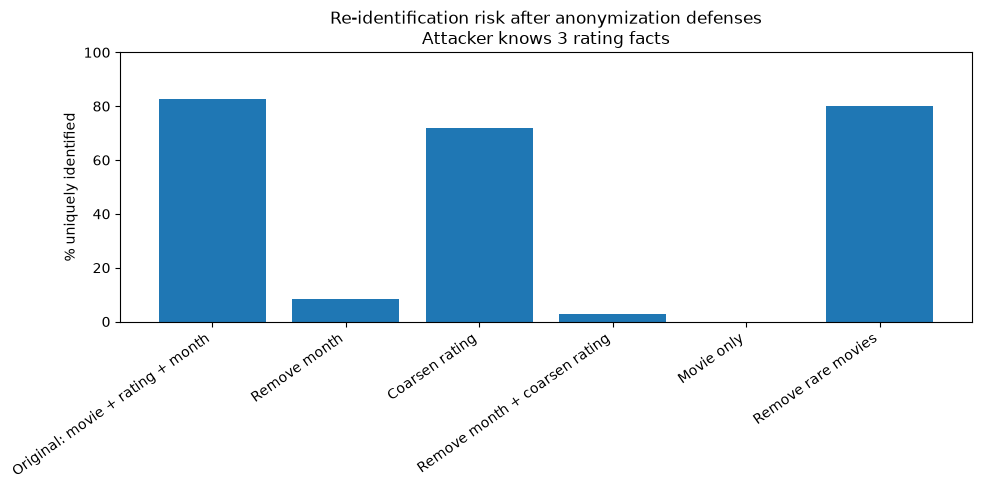

In [37]:
import matplotlib.pyplot as plt

chart_df = plot_df[plot_df["n_known"] == 3].sort_values("release_label")

plt.figure(figsize=(10, 5))
plt.bar(chart_df["release_label"].astype(str), chart_df["pct_unique"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("% uniquely identified")
plt.title("Re-identification risk after anonymization defenses\nAttacker knows 3 rating facts")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df_attack = df.copy()

if "date" in df_attack.columns:
    df_attack["date"] = pd.to_datetime(df_attack["date"])
    df_attack["year"] = df_attack["date"].dt.year

# Drop date/month from the actual attack dataframe.
df_attack = df_attack[["user_id", "movie_id", "rating", "year"]].copy()

df_attack["user_id"] = df_attack["user_id"].astype(int)
df_attack["movie_id"] = df_attack["movie_id"].astype(int)
df_attack["rating"] = df_attack["rating"].astype(int)
df_attack["year"] = df_attack["year"].astype(int)

print("ratings:", len(df_attack))
print("users:", df_attack["user_id"].nunique())
print("movies:", df_attack["movie_id"].nunique())
print("years:", sorted(df_attack["year"].unique()))

df_attack.head()

ratings: 10000000
users: 447845
movies: 1962
years: [np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005)]


,user_id,movie_id,rating,year
0,1488844,1,3,2005
1,822109,1,5,2005
2,885013,1,4,2005
3,30878,1,4,2005
4,823519,1,3,2004


In [39]:
# Attacker knowledge modes with NO date/month.
# The second one keeps year, which is much weaker than month/date but still temporal.

KNOWLEDGE_MODES_NO_MONTH = {
    "movie_rating_no_time": ["movie_id", "rating"],
    "movie_rating_year": ["movie_id", "rating", "year"],
}


def random_different_values(original_values, pool, rng):
    """
    Replace each value by a random DIFFERENT value from pool.
    """
    original_values = np.asarray(original_values)
    pool = np.asarray(pool)

    if len(pool) <= 1:
        return original_values.copy()

    new_values = rng.choice(pool, size=len(original_values))
    same = new_values == original_values

    while same.any():
        new_values[same] = rng.choice(pool, size=same.sum())
        same = new_values == original_values

    return new_values


def make_noisy_release(
    clean_data,
    rating_p=0.0,
    movie_p=0.0,
    user_p=0.0,
    seed=0
):
    """
    Create a noisy released dataset.

    rating_p: probability that a row's rating is changed to a different rating.
    movie_p: probability that a row's movie_id is changed to a different movie_id.
    user_p: probability that a row's user_id is changed to a different user_id.

    This is row-level noise.
    """
    rng = np.random.default_rng(seed)
    released = clean_data.copy()

    n = len(released)

    # Flip rating with probability rating_p
    if rating_p > 0:
        mask = rng.random(n) < rating_p
        released.loc[mask, "rating"] = random_different_values(
            released.loc[mask, "rating"].to_numpy(),
            pool=[1, 2, 3, 4, 5],
            rng=rng
        )

    # Change movie_id with probability movie_p
    if movie_p > 0:
        mask = rng.random(n) < movie_p
        released.loc[mask, "movie_id"] = random_different_values(
            released.loc[mask, "movie_id"].to_numpy(),
            pool=clean_data["movie_id"].unique(),
            rng=rng
        )

    # Change user_id / pseudonym with probability user_p
    if user_p > 0:
        mask = rng.random(n) < user_p
        released.loc[mask, "user_id"] = random_different_values(
            released.loc[mask, "user_id"].to_numpy(),
            pool=clean_data["user_id"].unique(),
            rng=rng
        )

    return released


def row_key(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def build_user_index(data, cols):
    """
    Maps each fact, e.g. (movie_id, rating), to the set of users having that fact.
    """
    small = data[cols + ["user_id"]].drop_duplicates()
    return small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()


def candidate_set_for_rows(known_rows, cols, index):
    """
    Return the set of released users matching all known facts.
    """
    candidates = None

    for _, row in known_rows.iterrows():
        key = row_key(row, cols)
        matching = index.get(key, set())

        if candidates is None:
            candidates = set(matching)
        else:
            candidates &= matching

        if len(candidates) == 0:
            break

    return candidates if candidates is not None else set()

In [40]:
# Histories are sampled from the TRUE clean data.
# The index is built from the NOISY released data.

clean_user_histories = {
    user_id: group
    for user_id, group in df_attack.groupby("user_id")
}

clean_user_counts = df_attack["user_id"].value_counts()


def evaluate_noisy_release(
    clean_data,
    released_data,
    scenario_name,
    p,
    knowledge_name,
    cols,
    n_known_values=[1, 2, 3, 4],
    trials=300,
    candidate_cutoff=5,
    seed=0
):
    """
    candidate_cutoff=5 means we count k < 5, i.e. 1,2,3,4 candidates.

    False positive among k < 5:
    candidate set is nonempty and has size < 5, but target_user is not in it.
    """
    rng = np.random.default_rng(seed)

    index = build_user_index(released_data, cols)

    results = []

    for n_known in n_known_values:
        eligible_users = clean_user_counts[clean_user_counts >= n_known].index.to_numpy()

        for _ in range(trials):
            target_user = int(rng.choice(eligible_users))
            history = clean_user_histories[target_user]

            known_rows = history.sample(
                n_known,
                random_state=int(rng.integers(0, 2**32 - 1))
            )

            candidates = candidate_set_for_rows(known_rows, cols, index)
            candidate_count = len(candidates)

            true_user_in_candidates = target_user in candidates

            less_than_5_candidates = (candidate_count > 0) and (candidate_count < candidate_cutoff)
            less_than_5_correct = less_than_5_candidates and true_user_in_candidates
            less_than_5_wrong = less_than_5_candidates and (not true_user_in_candidates)

            unique = candidate_count == 1
            unique_correct = unique and true_user_in_candidates
            unique_wrong = unique and (not true_user_in_candidates)

            results.append({
                "scenario": scenario_name,
                "p": p,
                "knowledge_name": knowledge_name,
                "knowledge_cols": " + ".join(cols),
                "n_known": n_known,
                "target_user": target_user,
                "candidate_count": candidate_count,

                "true_user_in_candidates": true_user_in_candidates,

                "less_than_5_candidates": less_than_5_candidates,
                "less_than_5_correct": less_than_5_correct,
                "less_than_5_wrong": less_than_5_wrong,

                "unique": unique,
                "unique_correct": unique_correct,
                "unique_wrong": unique_wrong,

                "no_match": candidate_count == 0,
            })

    return pd.DataFrame(results)


def summarize_noisy_results(results):
    summary = results.groupby(
        ["scenario", "p", "knowledge_name", "knowledge_cols", "n_known"]
    ).agg(
        trials=("candidate_count", "size"),

        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),

        pct_unique=("unique", lambda x: x.mean() * 100),
        pct_unique_correct=("unique_correct", lambda x: x.mean() * 100),
        pct_unique_wrong=("unique_wrong", lambda x: x.mean() * 100),

        pct_less_than_5_candidates=("less_than_5_candidates", lambda x: x.mean() * 100),
        pct_less_than_5_correct=("less_than_5_correct", lambda x: x.mean() * 100),
        pct_less_than_5_wrong=("less_than_5_wrong", lambda x: x.mean() * 100),

        pct_no_match=("no_match", lambda x: x.mean() * 100),

        less_than_5_count=("less_than_5_candidates", "sum"),
        less_than_5_wrong_count=("less_than_5_wrong", "sum"),
        unique_count=("unique", "sum"),
        unique_wrong_count=("unique_wrong", "sum"),
    ).reset_index()

    summary["false_positive_rate_among_less_than_5"] = (
        100 * summary["less_than_5_wrong_count"] / summary["less_than_5_count"].replace(0, np.nan)
    )

    summary["false_positive_rate_among_unique"] = (
        100 * summary["unique_wrong_count"] / summary["unique_count"].replace(0, np.nan)
    )

    summary["false_positive_rate_among_less_than_5"] = summary["false_positive_rate_among_less_than_5"].fillna(0)
    summary["false_positive_rate_among_unique"] = summary["false_positive_rate_among_unique"].fillna(0)

    return summary

In [41]:
p_values = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20]
trials = 300
n_known_values = [1, 2, 3, 4]

noise_scenarios = [
    "rating_noise",
    "movie_noise",
    "user_id_noise",
    "all_three_noise",
]

all_noise_results = []

base_seed = 12345
run_counter = 0

for scenario in noise_scenarios:
    for p in p_values:
        print("Making release:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0

        released_data = make_noisy_release(
            df_attack,
            rating_p=rating_p,
            movie_p=movie_p,
            user_p=user_p,
            seed=base_seed + run_counter
        )

        for knowledge_name, cols in KNOWLEDGE_MODES_NO_MONTH.items():
            print("  Evaluating:", knowledge_name)

            result = evaluate_noisy_release(
                clean_data=df_attack,
                released_data=released_data,
                scenario_name=scenario,
                p=p,
                knowledge_name=knowledge_name,
                cols=cols,
                n_known_values=n_known_values,
                trials=trials,
                candidate_cutoff=5,
                seed=base_seed + 10_000 + run_counter
            )

            all_noise_results.append(result)
            run_counter += 1

all_noise_results = pd.concat(all_noise_results, ignore_index=True)

noise_summary = summarize_noisy_results(all_noise_results)

noise_summary.head(20)

Making release: rating_noise p = 0.0
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.01
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.02
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.05
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.1
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.2
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.0
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.01
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.02
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.05
  Evaluating: movie_ratin

,scenario,p,knowledge_name,knowledge_cols,n_known,trials,avg_candidate_size,median_candidate_size,pct_unique,pct_unique_correct,...,pct_less_than_5_candidates,pct_less_than_5_correct,pct_less_than_5_wrong,pct_no_match,less_than_5_count,less_than_5_wrong_count,unique_count,unique_wrong_count,false_positive_rate_among_less_than_5,false_positive_rate_among_unique
0,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,1,300,19781.680000,13503.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
1,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,2,300,1582.233333,532.5,1.666667,1.666667,...,4.000000,4.000000,0.000000,0.000000,12,0,5,0,0.000000,0.000000
2,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,3,300,205.636667,49.0,8.333333,8.333333,...,19.666667,19.666667,0.000000,0.000000,59,0,25,0,0.000000,0.000000
3,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,4,300,44.093333,8.0,22.000000,22.000000,...,42.666667,42.666667,0.000000,0.000000,128,0,66,0,0.000000,0.000000
4,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,1,300,9517.916667,6149.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
5,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,2,300,686.103333,232.5,4.000000,4.000000,...,10.666667,10.666667,0.000000,0.000000,32,0,12,0,0.000000,0.000000
6,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,3,300,64.080000,8.0,27.333333,27.333333,...,40.333333,40.333333,0.000000,0.000000,121,0,82,0,0.000000,0.000000
7,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,4,300,10.206667,1.0,51.333333,51.333333,...,68.333333,68.333333,0.000000,0.000000,205,0,154,0,0.000000,0.000000
8,all_three_noise,0.01,movie_rating_no_time,movie_id + rating,1,300,18286.976667,13018.5,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
9,all_three_noise,0.01,movie_rating_no_time,movie_id + rating,2,300,1593.703333,613.5,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,6,0,0,0,0.000000,0.000000


In [42]:
# Main table: attacker knows 3 or 4 facts, and we track k < 5.

main_noise_table = noise_summary[
    noise_summary["n_known"].isin([3, 4])
].copy()

main_noise_table = main_noise_table[[
    "scenario",
    "p",
    "knowledge_name",
    "n_known",
    "median_candidate_size",
    "avg_candidate_size",
    "pct_unique",
    "pct_unique_correct",
    "pct_unique_wrong",
    "pct_less_than_5_candidates",
    "pct_less_than_5_correct",
    "pct_less_than_5_wrong",
    "false_positive_rate_among_less_than_5",
    "pct_no_match",
]]

main_noise_table = main_noise_table.sort_values(
    ["knowledge_name", "n_known", "scenario", "p"]
)

main_noise_table.style.format({
    "p": "{:.2f}",
    "median_candidate_size": "{:.1f}",
    "avg_candidate_size": "{:.1f}",
    "pct_unique": "{:.1f}%",
    "pct_unique_correct": "{:.1f}%",
    "pct_unique_wrong": "{:.1f}%",
    "pct_less_than_5_candidates": "{:.1f}%",
    "pct_less_than_5_correct": "{:.1f}%",
    "pct_less_than_5_wrong": "{:.1f}%",
    "false_positive_rate_among_less_than_5": "{:.1f}%",
    "pct_no_match": "{:.1f}%",
})

,scenario,p,knowledge_name,n_known,median_candidate_size,avg_candidate_size,pct_unique,pct_unique_correct,pct_unique_wrong,pct_less_than_5_candidates,pct_less_than_5_correct,pct_less_than_5_wrong,false_positive_rate_among_less_than_5,pct_no_match
2,all_three_noise,0.00,movie_rating_no_time,3,49.0,205.6,8.3%,8.3%,0.0%,19.7%,19.7%,0.0%,0.0%,0.0%
10,all_three_noise,0.01,movie_rating_no_time,3,64.5,219.2,6.3%,6.3%,0.0%,14.3%,14.3%,0.0%,0.0%,0.3%
18,all_three_noise,0.02,movie_rating_no_time,3,37.0,184.0,7.0%,6.3%,0.7%,19.7%,16.0%,3.7%,18.6%,2.7%
26,all_three_noise,0.05,movie_rating_no_time,3,31.0,178.7,9.0%,6.0%,3.0%,19.3%,12.7%,6.7%,34.5%,4.0%
34,all_three_noise,0.10,movie_rating_no_time,3,32.0,107.6,4.3%,2.3%,2.0%,13.7%,6.3%,7.3%,53.7%,3.3%
42,all_three_noise,0.20,movie_rating_no_time,3,18.0,59.4,7.7%,2.0%,5.7%,16.7%,3.3%,13.3%,80.0%,11.0%
50,movie_noise,0.00,movie_rating_no_time,3,63.5,258.4,6.7%,6.7%,0.0%,17.0%,17.0%,0.0%,0.0%,0.0%
58,movie_noise,0.01,movie_rating_no_time,3,47.0,190.9,9.7%,9.7%,0.0%,20.7%,20.3%,0.3%,1.6%,0.0%
66,movie_noise,0.02,movie_rating_no_time,3,57.5,201.1,7.7%,7.7%,0.0%,16.3%,15.3%,1.0%,6.1%,0.3%
74,movie_noise,0.05,movie_rating_no_time,3,37.0,158.9,9.7%,8.3%,1.3%,21.3%,18.3%,3.0%,14.1%,1.7%


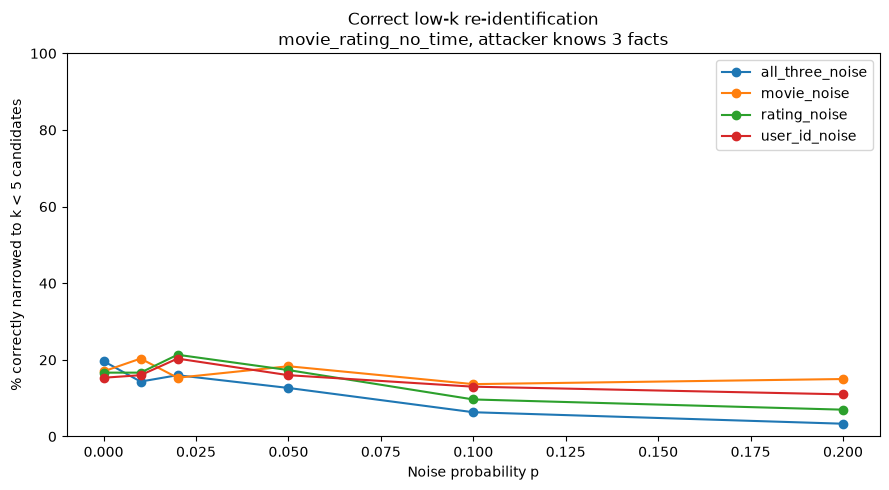

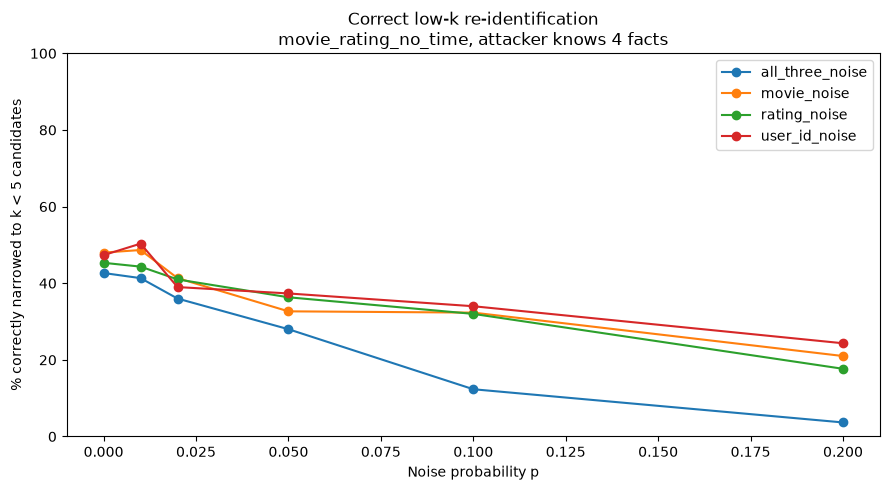

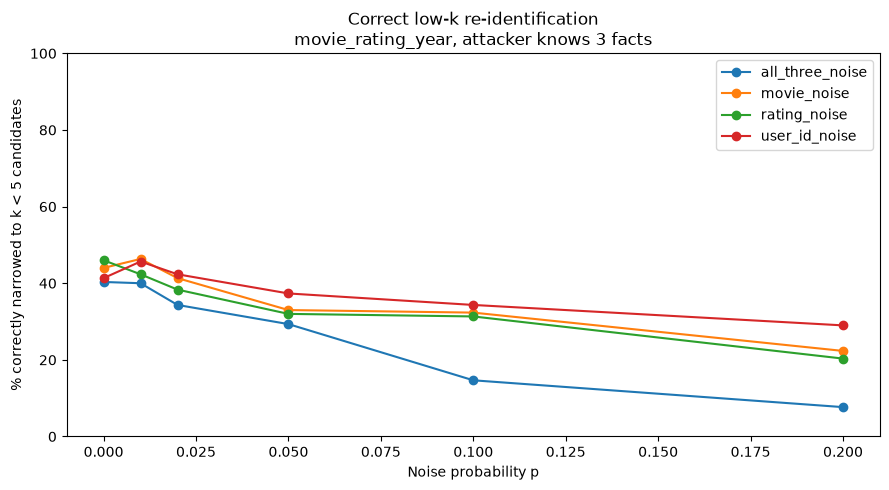

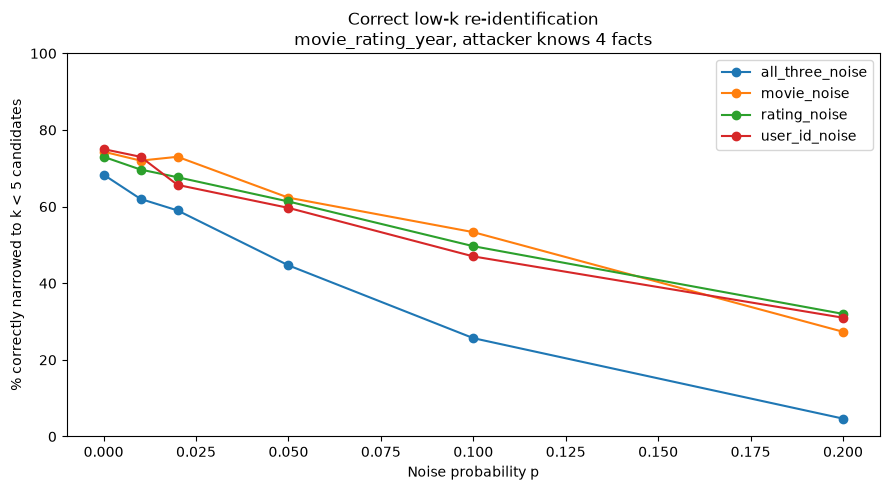

In [43]:
# Plot: percent of trials where the attack returns k < 5 candidates
# AND the true user is actually inside that small candidate set.

for knowledge_name in KNOWLEDGE_MODES_NO_MONTH.keys():
    for n_known in [3, 4]:
        chart_df = noise_summary[
            (noise_summary["knowledge_name"] == knowledge_name)
            & (noise_summary["n_known"] == n_known)
        ].copy()

        plt.figure(figsize=(9, 5))

        for scenario, part in chart_df.groupby("scenario"):
            part = part.sort_values("p")
            plt.plot(
                part["p"],
                part["pct_less_than_5_correct"],
                marker="o",
                label=scenario
            )

        plt.xlabel("Noise probability p")
        plt.ylabel("% correctly narrowed to k < 5 candidates")
        plt.title(f"Correct low-k re-identification\n{knowledge_name}, attacker knows {n_known} facts")
        plt.ylim(0, 100)
        plt.legend()
        plt.tight_layout()
        plt.show()

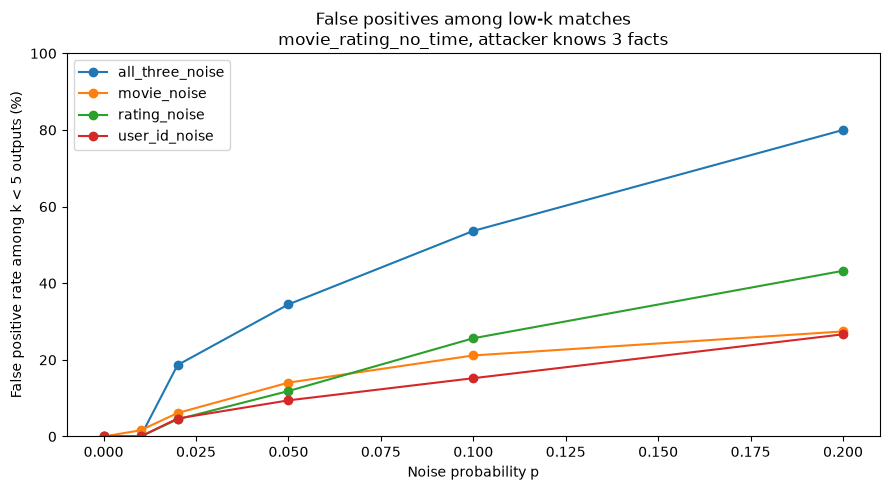

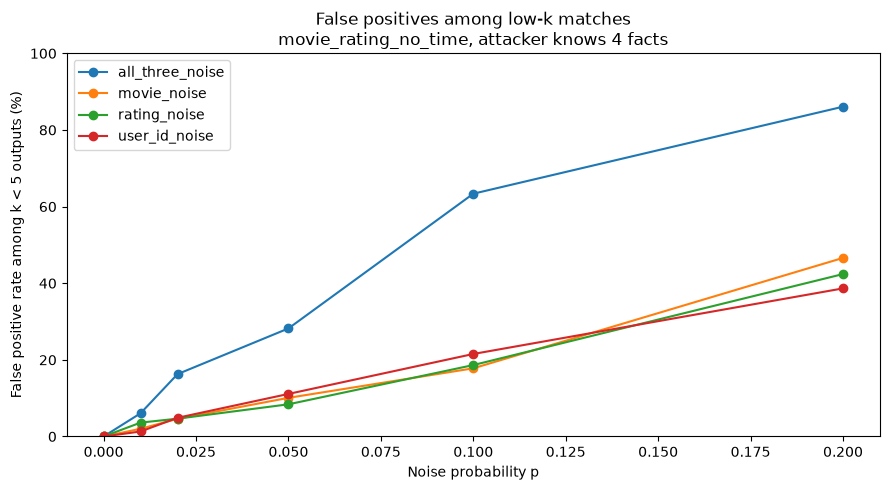

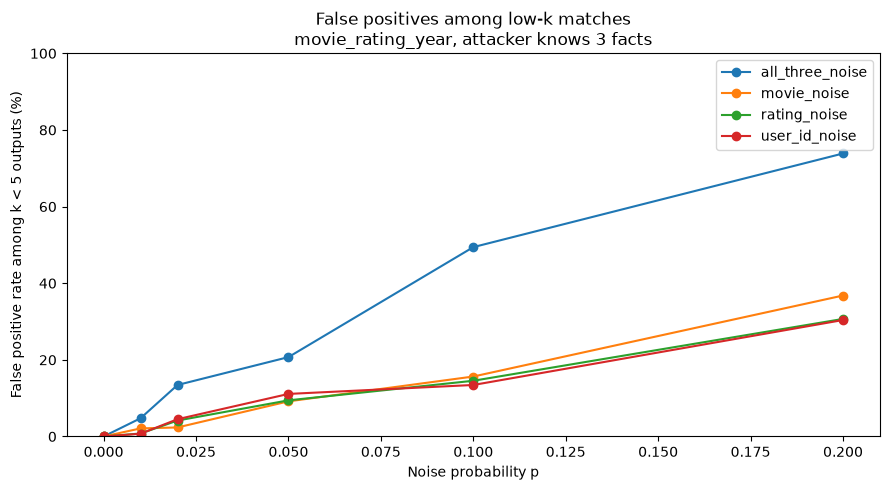

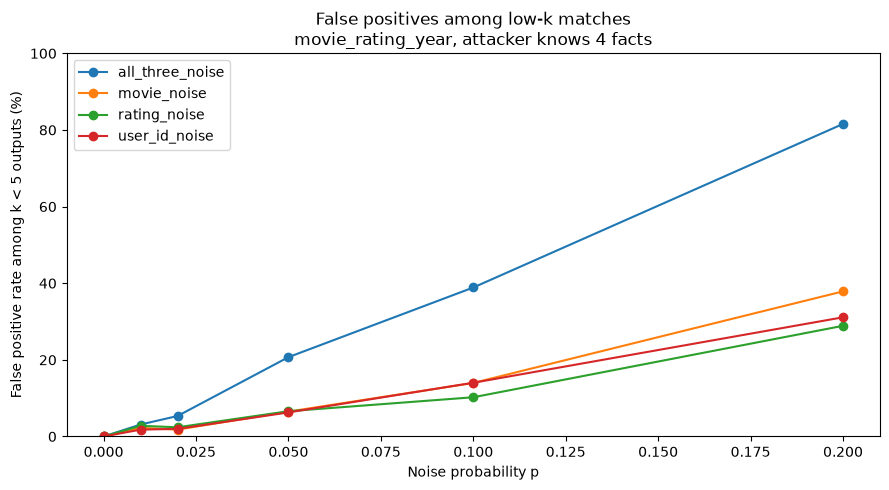

In [44]:
# Plot: among cases where the attack returns k < 5 candidates,
# how often is the true user NOT in that candidate set?

for knowledge_name in KNOWLEDGE_MODES_NO_MONTH.keys():
    for n_known in [3, 4]:
        chart_df = noise_summary[
            (noise_summary["knowledge_name"] == knowledge_name)
            & (noise_summary["n_known"] == n_known)
        ].copy()

        plt.figure(figsize=(9, 5))

        for scenario, part in chart_df.groupby("scenario"):
            part = part.sort_values("p")
            plt.plot(
                part["p"],
                part["false_positive_rate_among_less_than_5"],
                marker="o",
                label=scenario
            )

        plt.xlabel("Noise probability p")
        plt.ylabel("False positive rate among k < 5 outputs (%)")
        plt.title(f"False positives among low-k matches\n{knowledge_name}, attacker knows {n_known} facts")
        plt.ylim(0, 100)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [45]:
all_noise_results.to_csv("noise_attack_raw_results.csv", index=False)
noise_summary.to_csv("noise_attack_summary.csv", index=False)
main_noise_table.to_csv("noise_attack_main_table.csv", index=False)

print("Saved:")
print("noise_attack_raw_results.csv")
print("noise_attack_summary.csv")
print("noise_attack_main_table.csv")

Saved:
noise_attack_raw_results.csv
noise_attack_summary.csv
noise_attack_main_table.csv


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



UTILITY_SEED = 333
UTILITY_TEST_FRACTION = 0.20


UTILITY_SAMPLE_ROWS = None

BIAS_EPOCHS = 6
BIAS_REG = 10.0


def train_test_split_for_utility(frame, test_fraction=0.2, seed=333, sample_rows=None):
    data = frame[["user_id", "movie_id", "rating"]].dropna().copy()

    if sample_rows is not None and len(data) > sample_rows:
        data = data.sample(sample_rows, random_state=seed).copy()

    rng = np.random.default_rng(seed)
    is_test = rng.random(len(data)) < test_fraction

    train = data.loc[~is_test].reset_index(drop=True)
    test = data.loc[is_test].reset_index(drop=True)

    return train, test


def fit_bias_recommender(train, epochs=6, reg=10.0):
    """
    Fast recommender baseline:
        prediction = global_mean + user_bias + movie_bias

    This is much cheaper than fitting ALS for every noise setting.
    """
    train = train[["user_id", "movie_id", "rating"]].dropna().copy()

    user_codes, user_index = pd.factorize(train["user_id"], sort=False)
    movie_codes, movie_index = pd.factorize(train["movie_id"], sort=False)

    y = train["rating"].astype(float).to_numpy()
    global_mean = float(y.mean())

    user_bias = np.zeros(len(user_index), dtype=float)
    movie_bias = np.zeros(len(movie_index), dtype=float)

    user_counts = np.bincount(user_codes, minlength=len(user_index)).astype(float)
    movie_counts = np.bincount(movie_codes, minlength=len(movie_index)).astype(float)

    for _ in range(epochs):
        residual_for_users = y - global_mean - movie_bias[movie_codes]
        user_sums = np.bincount(user_codes, weights=residual_for_users, minlength=len(user_index))
        user_bias = user_sums / (user_counts + reg)

        residual_for_movies = y - global_mean - user_bias[user_codes]
        movie_sums = np.bincount(movie_codes, weights=residual_for_movies, minlength=len(movie_index))
        movie_bias = movie_sums / (movie_counts + reg)

    return {
        "global_mean": global_mean,
        "user_bias": pd.Series(user_bias, index=user_index),
        "movie_bias": pd.Series(movie_bias, index=movie_index),
    }


def predict_bias_recommender(model, test):
    pred = (
        model["global_mean"]
        + test["user_id"].map(model["user_bias"]).fillna(0).to_numpy()
        + test["movie_id"].map(model["movie_bias"]).fillna(0).to_numpy()
    )
    return np.clip(pred, 1, 5)


def recommender_metrics(y_true, y_pred):
    err = y_pred - y_true
    return {
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(np.abs(err))),
        "within_1_star_pct": float(np.mean(np.abs(err) <= 1.0) * 100),
    }


utility_train_clean, utility_test_clean = train_test_split_for_utility(
    df_attack,
    test_fraction=UTILITY_TEST_FRACTION,
    seed=UTILITY_SEED,
    sample_rows=UTILITY_SAMPLE_ROWS,
)

y_test = utility_test_clean["rating"].astype(float).to_numpy()

# Dumb baseline: always predict clean training mean.
global_pred = np.full(len(utility_test_clean), utility_train_clean["rating"].mean())
global_metrics = recommender_metrics(y_test, global_pred)
global_rmse = global_metrics["rmse"]

# Clean recommender baseline.
clean_model = fit_bias_recommender(
    utility_train_clean,
    epochs=BIAS_EPOCHS,
    reg=BIAS_REG,
)

clean_pred = predict_bias_recommender(clean_model, utility_test_clean)
clean_metrics = recommender_metrics(y_test, clean_pred)
clean_rmse = clean_metrics["rmse"]

print("Utility train rows:", len(utility_train_clean))
print("Utility test rows:", len(utility_test_clean))
print("Global mean baseline RMSE:", round(global_rmse, 4))
print("Clean recommender RMSE:", round(clean_rmse, 4))
print("Clean recommender within-1-star %:", round(clean_metrics["within_1_star_pct"], 2))

Utility train rows: 8000409
Utility test rows: 1999591
Global mean baseline RMSE: 1.0755
Clean recommender RMSE: 0.9388
Clean recommender within-1-star %: 72.46


In [47]:

utility_rows = []
utility_base_seed = 70000
utility_counter = 0

for scenario in noise_scenarios:
    for p in p_values:
        print("Utility eval:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0

        # Noise is applied only to the released training data.
        # The test set remains the true held-out ratings.
        noisy_train = make_noisy_release(
            utility_train_clean,
            rating_p=rating_p,
            movie_p=movie_p,
            user_p=user_p,
            seed=utility_base_seed + utility_counter,
        )

        model = fit_bias_recommender(
            noisy_train,
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

        pred = predict_bias_recommender(model, utility_test_clean)
        metrics = recommender_metrics(y_test, pred)

        utility_rows.append({
            "scenario": scenario,
            "p": p,
            "model": "bias_recommender",
            "rating_p": rating_p,
            "movie_p": movie_p,
            "user_p": user_p,
            **metrics,
        })

        utility_counter += 1

utility_summary = pd.DataFrame(utility_rows)

# RMSE-based utility retained:
# 100% = clean recommender
# 0% = global-mean-only recommender
if global_rmse > clean_rmse:
    utility_summary["rmse_utility_retained_pct"] = (
        100 * (global_rmse - utility_summary["rmse"]) / (global_rmse - clean_rmse)
    )
else:
    utility_summary["rmse_utility_retained_pct"] = np.nan

# Accuracy-style utility retained:
# 100% = same within-1-star accuracy as clean recommender.
utility_summary["within_1_star_retained_pct"] = (
    100 * utility_summary["within_1_star_pct"] / clean_metrics["within_1_star_pct"]
)

utility_summary["rmse_increase_vs_clean_pct"] = (
    100 * (utility_summary["rmse"] - clean_rmse) / clean_rmse
)

display(
    utility_summary.sort_values(["scenario", "p"])[[
        "scenario",
        "p",
        "rmse",
        "mae",
        "within_1_star_pct",
        "within_1_star_retained_pct",
        "rmse_utility_retained_pct",
        "rmse_increase_vs_clean_pct",
    ]]
)

utility_summary.to_csv("downstream_recommender_utility_summary.csv", index=False)
print("Saved downstream_recommender_utility_summary.csv")

Utility eval: rating_noise p = 0.0
Utility eval: rating_noise p = 0.01
Utility eval: rating_noise p = 0.02
Utility eval: rating_noise p = 0.05
Utility eval: rating_noise p = 0.1
Utility eval: rating_noise p = 0.2
Utility eval: movie_noise p = 0.0
Utility eval: movie_noise p = 0.01
Utility eval: movie_noise p = 0.02
Utility eval: movie_noise p = 0.05
Utility eval: movie_noise p = 0.1
Utility eval: movie_noise p = 0.2
Utility eval: user_id_noise p = 0.0
Utility eval: user_id_noise p = 0.01
Utility eval: user_id_noise p = 0.02
Utility eval: user_id_noise p = 0.05
Utility eval: user_id_noise p = 0.1
Utility eval: user_id_noise p = 0.2
Utility eval: all_three_noise p = 0.0
Utility eval: all_three_noise p = 0.01
Utility eval: all_three_noise p = 0.02
Utility eval: all_three_noise p = 0.05
Utility eval: all_three_noise p = 0.1
Utility eval: all_three_noise p = 0.2


,scenario,p,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct,rmse_increase_vs_clean_pct
18,all_three_noise,0.00,0.938766,0.740148,72.464819,100.000000,100.000000,0.000000
19,all_three_noise,0.01,0.940089,0.742441,72.232322,99.679158,99.032169,0.140942
20,all_three_noise,0.02,0.941576,0.744807,71.982270,99.334092,97.944706,0.299306
21,all_three_noise,0.05,0.946643,0.752436,71.214313,98.274327,94.237963,0.839107
22,all_three_noise,0.10,0.956537,0.766350,69.820378,96.350725,87.000618,1.893060
23,all_three_noise,0.20,0.983108,0.799559,66.833918,92.229469,67.564602,4.723466
6,movie_noise,0.00,0.938766,0.740148,72.464819,100.000000,100.000000,0.000000
7,movie_noise,0.01,0.939147,0.740554,72.437163,99.961836,99.721222,0.040598
8,movie_noise,0.02,0.939597,0.740968,72.406357,99.919324,99.391801,0.088570
9,movie_noise,0.05,0.940833,0.742124,72.329341,99.813043,98.488187,0.220161


Saved downstream_recommender_utility_summary.csv


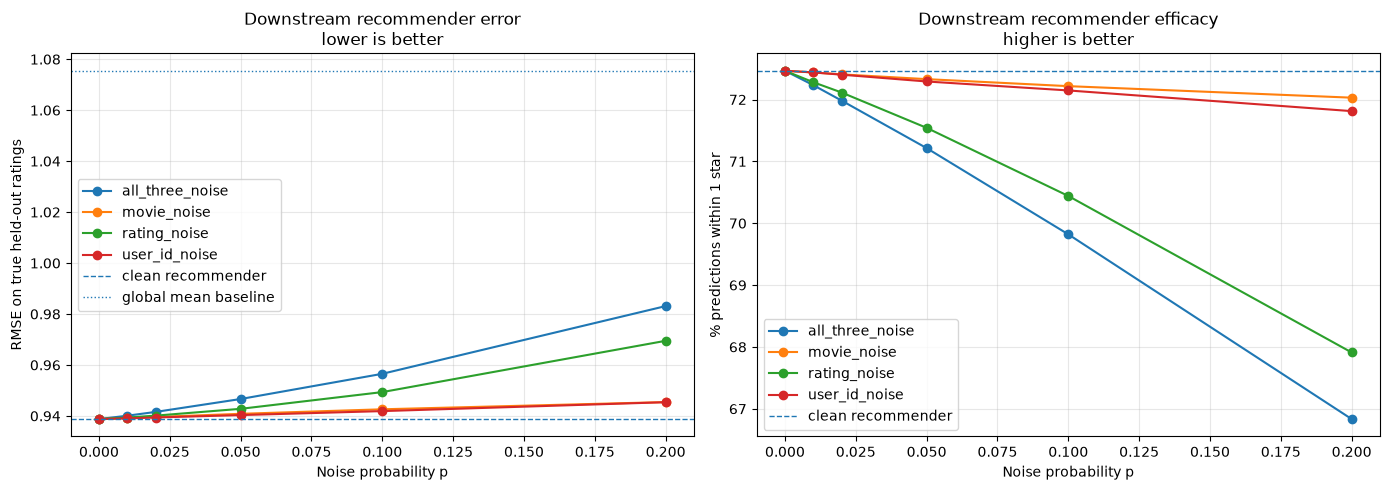

In [48]:
# -------------------------------------
# Plot downstream recommendation utility
# -------------------------------------

plot_utility = utility_summary.sort_values(["scenario", "p"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for scenario, part in plot_utility.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["rmse"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["within_1_star_pct"],
        marker="o",
        label=scenario,
    )

axes[0].axhline(clean_rmse, linestyle="--", linewidth=1, label="clean recommender")
axes[0].axhline(global_rmse, linestyle=":", linewidth=1, label="global mean baseline")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylabel("RMSE on true held-out ratings")
axes[0].set_title("Downstream recommender error\nlower is better")

axes[1].axhline(clean_metrics["within_1_star_pct"], linestyle="--", linewidth=1, label="clean recommender")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylabel("% predictions within 1 star")
axes[1].set_title("Downstream recommender efficacy\nhigher is better")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

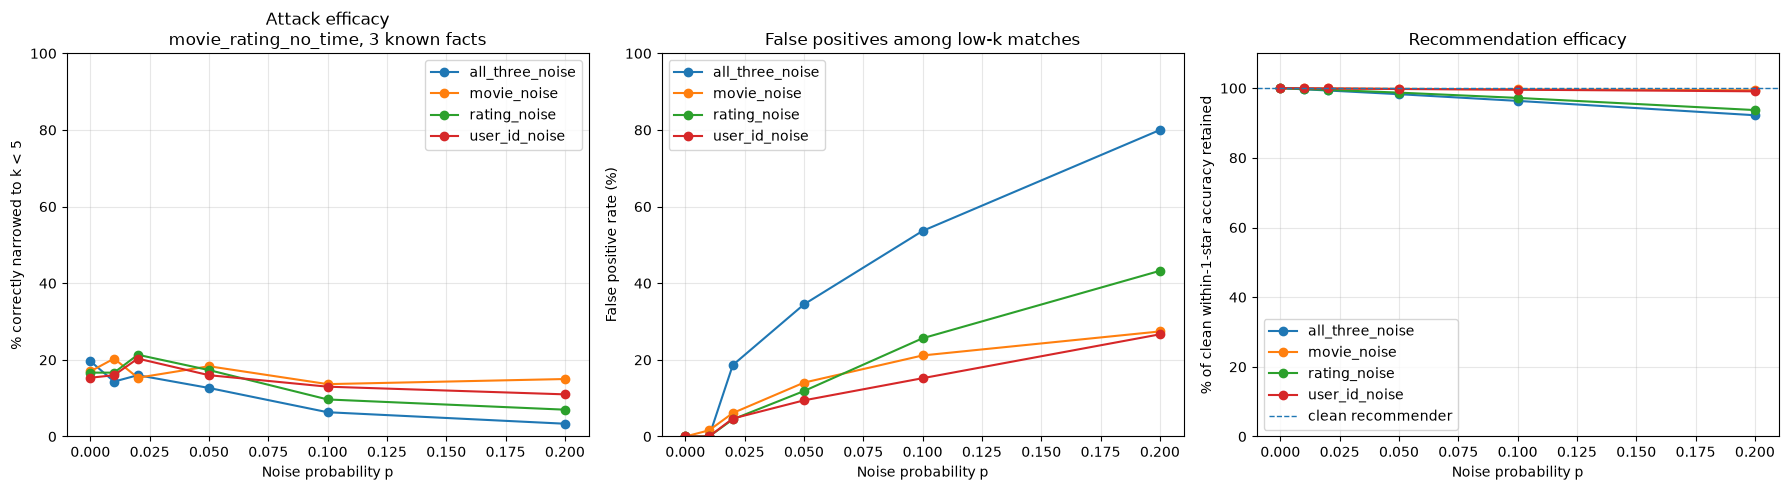

,scenario,p,pct_less_than_5_correct,false_positive_rate_among_less_than_5,rmse,mae,within_1_star_pct,within_1_star_retained_pct
0,all_three_noise,0.00,19.666667,0.000000,0.938766,0.740148,72.464819,100.000000
1,all_three_noise,0.01,14.333333,0.000000,0.940089,0.742441,72.232322,99.679158
2,all_three_noise,0.02,16.000000,18.644068,0.941576,0.744807,71.982270,99.334092
3,all_three_noise,0.05,12.666667,34.482759,0.946643,0.752436,71.214313,98.274327
4,all_three_noise,0.10,6.333333,53.658537,0.956537,0.766350,69.820378,96.350725
5,all_three_noise,0.20,3.333333,80.000000,0.983108,0.799559,66.833918,92.229469
6,movie_noise,0.00,17.000000,0.000000,0.938766,0.740148,72.464819,100.000000
7,movie_noise,0.01,20.333333,1.612903,0.939147,0.740554,72.437163,99.961836
8,movie_noise,0.02,15.333333,6.122449,0.939597,0.740968,72.406357,99.919324
9,movie_noise,0.05,18.333333,14.062500,0.940833,0.742124,72.329341,99.813043


Saved combined_privacy_utility_summary.csv


In [49]:


PLOT_KNOWLEDGE_NAME = "movie_rating_no_time"
PLOT_N_KNOWN = 3

privacy_for_plot = noise_summary[
    (noise_summary["knowledge_name"] == PLOT_KNOWLEDGE_NAME)
    & (noise_summary["n_known"] == PLOT_N_KNOWN)
].copy()

combined_summary = privacy_for_plot.merge(
    utility_summary,
    on=["scenario", "p"],
    how="left",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for scenario, part in combined_summary.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["pct_less_than_5_correct"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["false_positive_rate_among_less_than_5"],
        marker="o",
        label=scenario,
    )

    axes[2].plot(
        part["p"],
        part["within_1_star_retained_pct"],
        marker="o",
        label=scenario,
    )

axes[0].set_title(f"Attack efficacy\n{PLOT_KNOWLEDGE_NAME}, {PLOT_N_KNOWN} known facts")
axes[0].set_ylabel("% correctly narrowed to k < 5")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylim(0, 100)

axes[1].set_title("False positives among low-k matches")
axes[1].set_ylabel("False positive rate (%)")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylim(0, 100)

axes[2].axhline(100, linestyle="--", linewidth=1, label="clean recommender")
axes[2].set_title("Recommendation efficacy")
axes[2].set_ylabel("% of clean within-1-star accuracy retained")
axes[2].set_xlabel("Noise probability p")
axes[2].set_ylim(0, max(110, combined_summary["within_1_star_retained_pct"].max() * 1.05))

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

display(combined_summary[[
    "scenario",
    "p",
    "pct_less_than_5_correct",
    "false_positive_rate_among_less_than_5",
    "rmse",
    "mae",
    "within_1_star_pct",
    "within_1_star_retained_pct",
]].sort_values(["scenario", "p"]))

combined_summary.to_csv("combined_privacy_utility_summary.csv", index=False)
print("Saved combined_privacy_utility_summary.csv")

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UTILITY_SEED = 333
UTILITY_TEST_FRACTION = 0.20
UTILITY_SAMPLE_ROWS = None
BIAS_EPOCHS = 6
BIAS_REG = 10.0


class BiasRecommender:
    def __init__(self, global_mean, user_bias, item_bias, user_col, item_col):
        self.global_mean = global_mean
        self.user_bias = user_bias
        self.item_bias = item_bias
        self.user_col = user_col
        self.item_col = item_col

    def predict(self, frame):
        pred = (
            self.global_mean
            + frame[self.user_col].map(self.user_bias).fillna(0).to_numpy()
            + frame[self.item_col].map(self.item_bias).fillna(0).to_numpy()
        )
        return np.clip(pred, 1, 5)


def train_test_split_ratings(frame, test_fraction=0.2, seed=333, sample_rows=None):
    data = frame[["user_id", "movie_id", "rating"]].dropna().copy()
    data["rating"] = data["rating"].astype(float)

    if sample_rows is not None and len(data) > sample_rows:
        data = data.sample(sample_rows, random_state=seed).copy()

    rng = np.random.default_rng(seed)
    is_test = rng.random(len(data)) < test_fraction

    train = data.loc[~is_test].reset_index(drop=True)
    test = data.loc[is_test].reset_index(drop=True)

    return train, test


def fit_bias_recommender(frame, user_col="user_id", item_col="movie_id", rating_col="rating", epochs=6, reg=10.0):
    train = frame[[user_col, item_col, rating_col]].dropna().copy()
    train[rating_col] = train[rating_col].astype(float)

    user_codes, user_index = pd.factorize(train[user_col], sort=False)
    item_codes, item_index = pd.factorize(train[item_col], sort=False)

    y = train[rating_col].to_numpy(dtype=float)
    global_mean = float(y.mean())

    user_bias = np.zeros(len(user_index), dtype=float)
    item_bias = np.zeros(len(item_index), dtype=float)

    user_counts = np.bincount(user_codes, minlength=len(user_index)).astype(float)
    item_counts = np.bincount(item_codes, minlength=len(item_index)).astype(float)

    for _ in range(epochs):
        user_resid = y - global_mean - item_bias[item_codes]
        user_sums = np.bincount(user_codes, weights=user_resid, minlength=len(user_index))
        user_bias = user_sums / (user_counts + reg)

        item_resid = y - global_mean - user_bias[user_codes]
        item_sums = np.bincount(item_codes, weights=item_resid, minlength=len(item_index))
        item_bias = item_sums / (item_counts + reg)

    return BiasRecommender(
        global_mean=global_mean,
        user_bias=pd.Series(user_bias, index=user_index),
        item_bias=pd.Series(item_bias, index=item_index),
        user_col=user_col,
        item_col=item_col,
    )


def rmse(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.sqrt(np.mean((actual - pred) ** 2)))


def mae(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(actual - pred)))


def within_one_star(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(actual - pred) <= 1.0) * 100)


utility_train_clean, utility_test_clean = train_test_split_ratings(
    df_attack,
    test_fraction=UTILITY_TEST_FRACTION,
    seed=UTILITY_SEED,
    sample_rows=UTILITY_SAMPLE_ROWS,
)

actual = utility_test_clean["rating"].to_numpy(dtype=float)

global_pred = np.full(len(utility_test_clean), utility_train_clean["rating"].mean())
global_rmse = rmse(actual, global_pred)
global_mae = mae(actual, global_pred)
global_within_1 = within_one_star(actual, global_pred)

clean_model = fit_bias_recommender(
    utility_train_clean,
    user_col="user_id",
    item_col="movie_id",
    rating_col="rating",
    epochs=BIAS_EPOCHS,
    reg=BIAS_REG,
)

clean_pred = clean_model.predict(utility_test_clean)
clean_rmse = rmse(actual, clean_pred)
clean_mae = mae(actual, clean_pred)
clean_within_1 = within_one_star(actual, clean_pred)

print("train rows:", len(utility_train_clean))
print("test rows:", len(utility_test_clean))
print("global rmse:", round(global_rmse, 4))
print("clean bias rmse:", round(clean_rmse, 4))
print("clean bias mae:", round(clean_mae, 4))
print("clean bias within 1 star:", round(clean_within_1, 2))

train rows: 8000409
test rows: 1999591
global rmse: 1.0755
clean bias rmse: 0.9388
clean bias mae: 0.7401
clean bias within 1 star: 72.46


In [51]:
utility_rows = []
utility_base_seed = 70000
utility_counter = 0

for scenario in noise_scenarios:
    for p in p_values:
        print("Utility eval:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0

        noisy_train = make_noisy_release(
            utility_train_clean,
            rating_p=rating_p,
            movie_p=movie_p,
            user_p=user_p,
            seed=utility_base_seed + utility_counter,
        )

        model = fit_bias_recommender(
            noisy_train,
            user_col="user_id",
            item_col="movie_id",
            rating_col="rating",
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

        pred = model.predict(utility_test_clean)

        utility_rows.append({
            "scenario": scenario,
            "p": p,
            "model": "bias",
            "rating_p": rating_p,
            "movie_p": movie_p,
            "user_p": user_p,
            "rmse": rmse(actual, pred),
            "mae": mae(actual, pred),
            "within_1_star_pct": within_one_star(actual, pred),
        })

        utility_counter += 1

utility_summary = pd.DataFrame(utility_rows)

utility_summary["rmse_increase_vs_clean_pct"] = (
    100 * (utility_summary["rmse"] - clean_rmse) / clean_rmse
)

utility_summary["mae_increase_vs_clean_pct"] = (
    100 * (utility_summary["mae"] - clean_mae) / clean_mae
)

utility_summary["within_1_star_retained_pct"] = (
    100 * utility_summary["within_1_star_pct"] / clean_within_1
)

if global_rmse > clean_rmse:
    utility_summary["rmse_utility_retained_pct"] = (
        100 * (global_rmse - utility_summary["rmse"]) / (global_rmse - clean_rmse)
    )
else:
    utility_summary["rmse_utility_retained_pct"] = np.nan

display(
    utility_summary.sort_values(["scenario", "p"])[[
        "scenario",
        "p",
        "model",
        "rmse",
        "mae",
        "within_1_star_pct",
        "within_1_star_retained_pct",
        "rmse_utility_retained_pct",
        "rmse_increase_vs_clean_pct",
        "mae_increase_vs_clean_pct",
    ]]
)

utility_summary.to_csv("downstream_bias_recommender_utility_summary.csv", index=False)
print("Saved downstream_bias_recommender_utility_summary.csv")

Utility eval: rating_noise p = 0.0
Utility eval: rating_noise p = 0.01
Utility eval: rating_noise p = 0.02
Utility eval: rating_noise p = 0.05
Utility eval: rating_noise p = 0.1
Utility eval: rating_noise p = 0.2
Utility eval: movie_noise p = 0.0
Utility eval: movie_noise p = 0.01
Utility eval: movie_noise p = 0.02
Utility eval: movie_noise p = 0.05
Utility eval: movie_noise p = 0.1
Utility eval: movie_noise p = 0.2
Utility eval: user_id_noise p = 0.0
Utility eval: user_id_noise p = 0.01
Utility eval: user_id_noise p = 0.02
Utility eval: user_id_noise p = 0.05
Utility eval: user_id_noise p = 0.1
Utility eval: user_id_noise p = 0.2
Utility eval: all_three_noise p = 0.0
Utility eval: all_three_noise p = 0.01
Utility eval: all_three_noise p = 0.02
Utility eval: all_three_noise p = 0.05
Utility eval: all_three_noise p = 0.1
Utility eval: all_three_noise p = 0.2


,scenario,p,model,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct,rmse_increase_vs_clean_pct,mae_increase_vs_clean_pct
18,all_three_noise,0.00,bias,0.938766,0.740148,72.464819,100.000000,100.000000,0.000000,0.000000
19,all_three_noise,0.01,bias,0.940089,0.742441,72.232322,99.679158,99.032169,0.140942,0.309781
20,all_three_noise,0.02,bias,0.941576,0.744807,71.982270,99.334092,97.944706,0.299306,0.629460
21,all_three_noise,0.05,bias,0.946643,0.752436,71.214313,98.274327,94.237963,0.839107,1.660300
22,all_three_noise,0.10,bias,0.956537,0.766350,69.820378,96.350725,87.000618,1.893060,3.540084
23,all_three_noise,0.20,bias,0.983108,0.799559,66.833918,92.229469,67.564602,4.723466,8.026897
6,movie_noise,0.00,bias,0.938766,0.740148,72.464819,100.000000,100.000000,0.000000,0.000000
7,movie_noise,0.01,bias,0.939147,0.740554,72.437163,99.961836,99.721222,0.040598,0.054914
8,movie_noise,0.02,bias,0.939597,0.740968,72.406357,99.919324,99.391801,0.088570,0.110777
9,movie_noise,0.05,bias,0.940833,0.742124,72.329341,99.813043,98.488187,0.220161,0.267020


Saved downstream_bias_recommender_utility_summary.csv


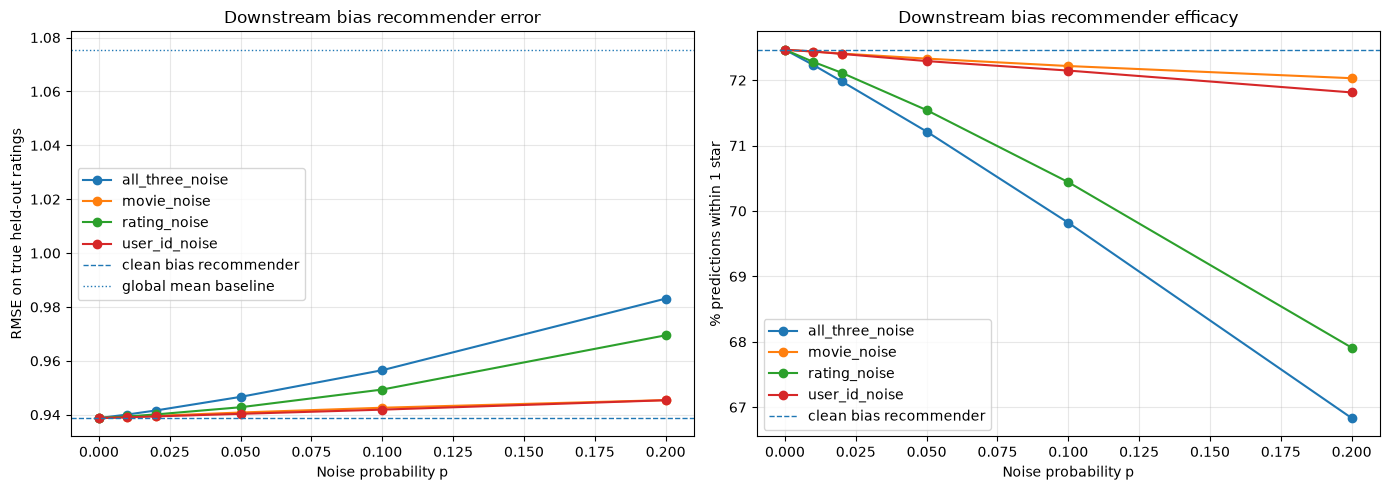

In [52]:
plot_utility = utility_summary.sort_values(["scenario", "p"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for scenario, part in plot_utility.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["rmse"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["within_1_star_pct"],
        marker="o",
        label=scenario,
    )

axes[0].axhline(clean_rmse, linestyle="--", linewidth=1, label="clean bias recommender")
axes[0].axhline(global_rmse, linestyle=":", linewidth=1, label="global mean baseline")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylabel("RMSE on true held-out ratings")
axes[0].set_title("Downstream bias recommender error")

axes[1].axhline(clean_within_1, linestyle="--", linewidth=1, label="clean bias recommender")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylabel("% predictions within 1 star")
axes[1].set_title("Downstream bias recommender efficacy")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

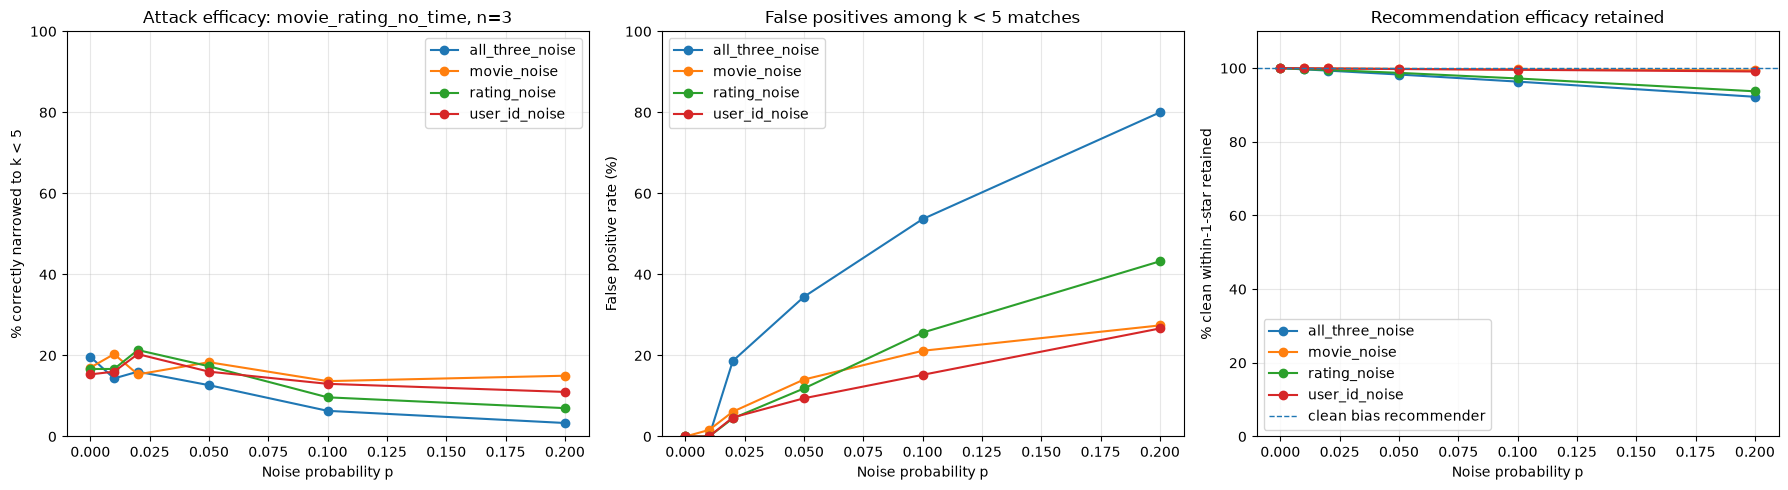

,scenario,p,pct_less_than_5_correct,false_positive_rate_among_less_than_5,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct
0,all_three_noise,0.00,19.666667,0.000000,0.938766,0.740148,72.464819,100.000000,100.000000
1,all_three_noise,0.01,14.333333,0.000000,0.940089,0.742441,72.232322,99.679158,99.032169
2,all_three_noise,0.02,16.000000,18.644068,0.941576,0.744807,71.982270,99.334092,97.944706
3,all_three_noise,0.05,12.666667,34.482759,0.946643,0.752436,71.214313,98.274327,94.237963
4,all_three_noise,0.10,6.333333,53.658537,0.956537,0.766350,69.820378,96.350725,87.000618
5,all_three_noise,0.20,3.333333,80.000000,0.983108,0.799559,66.833918,92.229469,67.564602
6,movie_noise,0.00,17.000000,0.000000,0.938766,0.740148,72.464819,100.000000,100.000000
7,movie_noise,0.01,20.333333,1.612903,0.939147,0.740554,72.437163,99.961836,99.721222
8,movie_noise,0.02,15.333333,6.122449,0.939597,0.740968,72.406357,99.919324,99.391801
9,movie_noise,0.05,18.333333,14.062500,0.940833,0.742124,72.329341,99.813043,98.488187


Saved combined_privacy_bias_utility_summary.csv


In [53]:
PLOT_KNOWLEDGE_NAME = "movie_rating_no_time"
PLOT_N_KNOWN = 3

privacy_for_plot = noise_summary[
    (noise_summary["knowledge_name"] == PLOT_KNOWLEDGE_NAME)
    & (noise_summary["n_known"] == PLOT_N_KNOWN)
].copy()

combined_summary = privacy_for_plot.merge(
    utility_summary,
    on=["scenario", "p"],
    how="left",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for scenario, part in combined_summary.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["pct_less_than_5_correct"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["false_positive_rate_among_less_than_5"],
        marker="o",
        label=scenario,
    )

    axes[2].plot(
        part["p"],
        part["within_1_star_retained_pct"],
        marker="o",
        label=scenario,
    )

axes[0].set_title(f"Attack efficacy: {PLOT_KNOWLEDGE_NAME}, n={PLOT_N_KNOWN}")
axes[0].set_ylabel("% correctly narrowed to k < 5")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylim(0, 100)

axes[1].set_title("False positives among k < 5 matches")
axes[1].set_ylabel("False positive rate (%)")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylim(0, 100)

axes[2].axhline(100, linestyle="--", linewidth=1, label="clean bias recommender")
axes[2].set_title("Recommendation efficacy retained")
axes[2].set_ylabel("% clean within-1-star retained")
axes[2].set_xlabel("Noise probability p")
axes[2].set_ylim(0, max(110, combined_summary["within_1_star_retained_pct"].max() * 1.05))

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

display(combined_summary[[
    "scenario",
    "p",
    "pct_less_than_5_correct",
    "false_positive_rate_among_less_than_5",
    "rmse",
    "mae",
    "within_1_star_pct",
    "within_1_star_retained_pct",
    "rmse_utility_retained_pct",
]].sort_values(["scenario", "p"]))

combined_summary.to_csv("combined_privacy_bias_utility_summary.csv", index=False)
print("Saved combined_privacy_bias_utility_summary.csv")

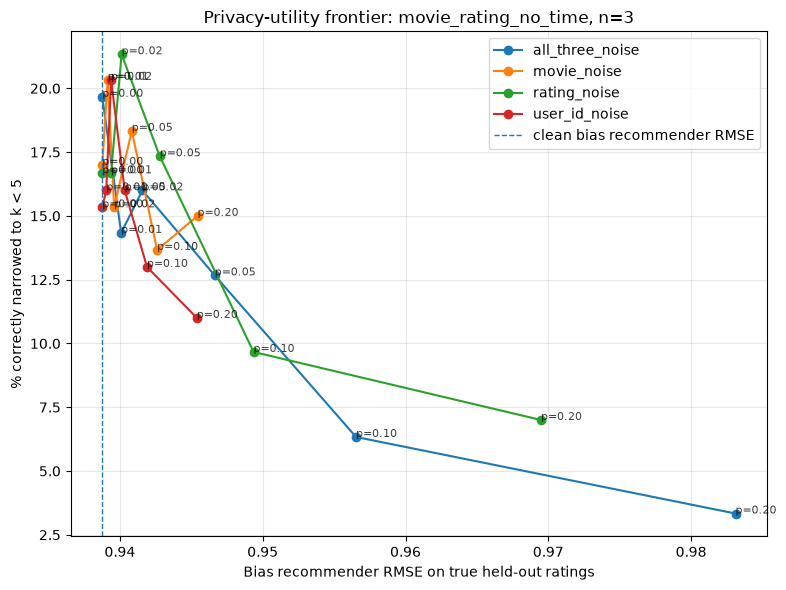

In [54]:
frontier_df = combined_summary.dropna(subset=["rmse", "pct_less_than_5_correct"]).copy()

plt.figure(figsize=(8, 6))

for scenario, part in frontier_df.groupby("scenario"):
    part = part.sort_values("p")

    plt.plot(
        part["rmse"],
        part["pct_less_than_5_correct"],
        marker="o",
        label=scenario,
    )

    for _, row in part.iterrows():
        plt.annotate(
            f"p={row['p']:.2f}",
            (row["rmse"], row["pct_less_than_5_correct"]),
            fontsize=8,
            alpha=0.75,
        )

plt.axvline(clean_rmse, linestyle="--", linewidth=1, label="clean bias recommender RMSE")
plt.xlabel("Bias recommender RMSE on true held-out ratings")
plt.ylabel("% correctly narrowed to k < 5")
plt.title(f"Privacy-utility frontier: {PLOT_KNOWLEDGE_NAME}, n={PLOT_N_KNOWN}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
!pip -q install pyspark

import gc
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

KNN_K = 30
KNN_MIN_SIMILARITY = 0.05
ALS_RANK = 70
ALS_MAX_ITER = 10
ALS_REG = 0.1

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("NetflixNoiseUtility")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.driver.memory", "12g")  # Allocate 14 GB to the driver
    .getOrCreate()
)


spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 02:30:28 WARN Utils: Your hostname, Ericks-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.159 instead (on interface en0)
26/07/11 02:30:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/11 02:30:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/11 02:30:29 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [56]:
class ItemKNNRecommender:
    def __init__(self, baseline, item_to_code, similarity_matrix, user_history):
        self.baseline = baseline
        self.item_to_code = item_to_code
        self.similarity_matrix = similarity_matrix
        self.user_history = user_history

    def predict(self, frame):
        pred = self.baseline.predict(frame).astype(float)
        users = frame["user_id"].to_numpy()
        items = frame["movie_id"].to_numpy()

        for row_idx, (user_id, item_id) in enumerate(zip(users, items)):
            target_code = self.item_to_code.get(item_id)
            history = self.user_history.get(user_id)

            if target_code is None or history is None:
                continue

            history_codes, history_residuals = history
            weights = self.similarity_matrix[target_code, history_codes]
            valid = weights > 0

            if valid.any():
                pred[row_idx] += float(
                    np.dot(weights[valid], history_residuals[valid])
                    / np.abs(weights[valid]).sum()
                )

        return np.clip(pred, 1, 5)


def fit_item_knn_recommender(
    train,
    baseline_model=None,
    k=30,
    min_similarity=0.05,
):
    work = train[["user_id", "movie_id", "rating"]].dropna().copy()
    work = work.groupby(["user_id", "movie_id"], as_index=False)["rating"].mean()

    baseline = baseline_model

    if baseline is None:
        baseline = fit_bias_recommender(
            work,
            user_col="user_id",
            item_col="movie_id",
            rating_col="rating",
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

    residuals = work["rating"].to_numpy(dtype=float) - baseline.predict(work)

    user_codes, user_ids = pd.factorize(work["user_id"], sort=False)
    item_codes, item_ids = pd.factorize(work["movie_id"], sort=False)

    item_user_residuals = csr_matrix(
        (residuals, (item_codes, user_codes)),
        shape=(len(item_ids), len(user_ids)),
    )

    n_neighbors = min(k + 1, len(item_ids))

    neighbor_model = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1,
    )

    neighbor_model.fit(item_user_residuals)

    distances, neighbor_codes = neighbor_model.kneighbors(
        item_user_residuals,
        return_distance=True,
    )

    similarity_matrix = np.zeros(
        (len(item_ids), len(item_ids)),
        dtype=np.float32,
    )

    for item_code in range(len(item_ids)):
        codes = neighbor_codes[item_code]
        similarities = 1.0 - distances[item_code]
        keep = (codes != item_code) & (similarities >= min_similarity)
        similarity_matrix[item_code, codes[keep]] = similarities[keep].astype(
            np.float32
        )

    order = np.argsort(user_codes, kind="stable")
    counts = np.bincount(user_codes, minlength=len(user_ids))
    stops = np.cumsum(counts)
    starts = np.concatenate(([0], stops[:-1]))

    user_history = {}

    for user_code, user_id in enumerate(user_ids):
        positions = order[starts[user_code]:stops[user_code]]
        user_history[user_id] = (
            item_codes[positions],
            residuals[positions],
        )

    item_to_code = {
        item_id: item_code
        for item_code, item_id in enumerate(item_ids)
    }

    return ItemKNNRecommender(
        baseline=baseline,
        item_to_code=item_to_code,
        similarity_matrix=similarity_matrix,
        user_history=user_history,
    )

In [57]:
class SparkALSRecommender:
    def __init__(self, baseline, model):
        self.baseline = baseline
        self.model = model

    def predict(self, frame):
        base_pred = self.baseline.predict(frame).astype(float)

        prediction_input = pd.DataFrame({
            "_row_id": np.arange(len(frame), dtype=np.int64),
            "user_id": frame["user_id"].to_numpy(dtype=np.int32),
            "movie_id": frame["movie_id"].to_numpy(dtype=np.int32),
        })

        prediction_spark = spark.createDataFrame(prediction_input)

        prediction_output = (
            self.model
            .transform(prediction_spark)
            .select("_row_id", "prediction")
            .toPandas()
        )

        residual_pred = np.zeros(len(frame), dtype=float)

        if len(prediction_output) > 0:
            row_ids = prediction_output["_row_id"].to_numpy(dtype=int)
            values = prediction_output["prediction"].to_numpy(dtype=float)
            finite = np.isfinite(values)
            residual_pred[row_ids[finite]] = values[finite]

        return np.clip(base_pred + residual_pred, 1, 5)


def fit_als_recommender(
    train,
    baseline_model=None,
    rank = 30,
    max_iter=10,
    reg_param=0.05,
    seed=333,
):
    work = train[["user_id", "movie_id", "rating"]].dropna().copy()
    work = work.groupby(["user_id", "movie_id"], as_index=False)["rating"].mean()

    baseline = baseline_model

    if baseline is None:
        baseline = fit_bias_recommender(
            work,
            user_col="user_id",
            item_col="movie_id",
            rating_col="rating",
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

    work["residual"] = (
        work["rating"].to_numpy(dtype=float)
        - baseline.predict(work)
    )

    als_input = work[["user_id", "movie_id", "residual"]].copy()
    als_input["user_id"] = als_input["user_id"].astype(np.int32)
    als_input["movie_id"] = als_input["movie_id"].astype(np.int32)
    als_input["residual"] = als_input["residual"].astype(np.float32)

    als_spark = spark.createDataFrame(als_input)

    als_spark.cache()
    als_spark.count()

    estimator = ALS(
        userCol="user_id",
        itemCol="movie_id",
        ratingCol="residual",
        rank=rank,
        maxIter=max_iter,
        regParam=reg_param,
        implicitPrefs=False,
        nonnegative=False,
        coldStartStrategy="drop",
        seed=seed,
        numUserBlocks=8,
        numItemBlocks=4,
        checkpointInterval=-1,
    )

    return SparkALSRecommender(
        baseline=baseline,
        model=estimator.fit(als_spark),
    )

In [58]:
clean_knn_model = fit_item_knn_recommender(
    utility_train_clean,
    baseline_model=clean_model,
    k=KNN_K,
    min_similarity=KNN_MIN_SIMILARITY,
)

clean_knn_pred = clean_knn_model.predict(utility_test_clean)

clean_als_model = fit_als_recommender(
    utility_train_clean,
    baseline_model=clean_model,
    rank=ALS_RANK,
    max_iter=ALS_MAX_ITER,
    reg_param=ALS_REG,
    seed=UTILITY_SEED,
)

clean_als_pred = clean_als_model.predict(utility_test_clean)

clean_model_comparison = pd.DataFrame([
    {
        "model": "Bias",
        "rmse": clean_rmse,
        "mae": clean_mae,
        "within_1_star_pct": clean_within_1,
    },
    {
        "model": "Item KNN",
        "rmse": rmse(actual, clean_knn_pred),
        "mae": mae(actual, clean_knn_pred),
        "within_1_star_pct": within_one_star(actual, clean_knn_pred),
    },
    {
        "model": "ALS",
        "rmse": rmse(actual, clean_als_pred),
        "mae": mae(actual, clean_als_pred),
        "within_1_star_pct": within_one_star(actual, clean_als_pred),
    },
])

display(clean_model_comparison)

,model,rmse,mae,within_1_star_pct
0,Bias,0.938766,0.740148,72.464819
1,Item KNN,0.973499,0.746506,72.734674
2,ALS,0.907167,0.708069,75.054799


In [ ]:
# regParams = [0.01, 0.05, 0.1]
# ranks = [20,50,100]
# iterations = [10,15,20]
# param_data = {}

# for reg in regParams:
#     for rank in ranks:
#         for iteration in iterations:
#             clean_als_model = fit_als_recommender(
#                 utility_train_clean,
#                 baseline_model=clean_model,
#                 rank=rank,
#                 max_iter=iteration,
#                 reg_param=reg,
#                 seed=UTILITY_SEED,
#             )

#             clean_als_pred = clean_als_model.predict(utility_test_clean)

#             rmse_pt = rmse(actual, clean_als_pred)

#             param_data[(reg, rank, iteration)] = rmse_pt

#             print('Regularization Paramter: ', reg, ' ; ALS Rank: ', rank, ' ; Iterations: ', iteration)
#             print('RMSE: ', rmse_pt)

            

                    


Regularization Paramter:  0.01  ; ALS Rank:  20  ; Iterations:  10
RMSE:  1.0648521290070367


Regularization Paramter:  0.01  ; ALS Rank:  20  ; Iterations:  15
RMSE:  1.0669976478799363


Regularization Paramter:  0.01  ; ALS Rank:  20  ; Iterations:  20
RMSE:  1.0641062060982491


Regularization Paramter:  0.01  ; ALS Rank:  50  ; Iterations:  10
RMSE:  1.0523563555117437


Regularization Paramter:  0.01  ; ALS Rank:  50  ; Iterations:  15
RMSE:  1.0559474079573163


...

Regularization Paramter:  0.1  ; ALS Rank:  50  ; Iterations:  15
RMSE:  0.9076737712639071


Regularization Paramter:  0.1  ; ALS Rank:  50  ; Iterations:  20
RMSE:  0.907282043967021


Regularization Paramter:  0.1  ; ALS Rank:  100  ; Iterations:  10
RMSE:  0.9059497719813415


Regularization Paramter:  0.1  ; ALS Rank:  100  ; Iterations:  15
RMSE:  0.9054189648303966


Regularization Paramter:  0.1  ; ALS Rank:  100  ; Iterations:  20
RMSE:  0.9052837479785233


In [ ]:
# for reg in [0.1,0.15,0.2]:
#             clean_als_model = fit_als_recommender(
#                 utility_train_clean,
#                 baseline_model=clean_model,
#                 rank=50,
#                 max_iter=15,
#                 reg_param=reg,
#                 seed=UTILITY_SEED,
#             )

#             clean_als_pred = clean_als_model.predict(utility_test_clean)

#             rmse_pt = rmse(actual, clean_als_pred)

#             param_data[(reg, 50, 15)] = rmse_pt

#             print('Regularization Paramter: ', reg, ' ; ALS Rank: ', 50, ' ; Iterations: ', 15)
#             print('RMSE: ', rmse_pt)

Regularization Paramter:  0.1  ; ALS Rank:  50  ; Iterations:  15
RMSE:  0.9076737712639071


Regularization Paramter:  0.15  ; ALS Rank:  50  ; Iterations:  15
RMSE:  0.9113938681952924


Regularization Paramter:  0.2  ; ALS Rank:  50  ; Iterations:  15
RMSE:  0.9212227335912966


In [59]:
advanced_rows = []
utility_base_seed = 70000
utility_counter = 0

clean_metric_lookup = clean_model_comparison.set_index("model").to_dict("index")

for scenario in noise_scenarios:
    for p in p_values:
        print("Advanced utility eval:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0
        release_seed = utility_base_seed + utility_counter

        if p == 0:
            for model_name in ["Item KNN", "ALS"]:
                advanced_rows.append({
                    "scenario": scenario,
                    "p": p,
                    "model": model_name,
                    "rating_p": rating_p,
                    "movie_p": movie_p,
                    "user_p": user_p,
                    **clean_metric_lookup[model_name],
                })
        else:
            noisy_train = make_noisy_release(
                utility_train_clean,
                rating_p=rating_p,
                movie_p=movie_p,
                user_p=user_p,
                seed=release_seed,
            )

            noisy_bias_model = fit_bias_recommender(
                noisy_train,
                user_col="user_id",
                item_col="movie_id",
                rating_col="rating",
                epochs=BIAS_EPOCHS,
                reg=BIAS_REG,
            )

            knn_model = fit_item_knn_recommender(
                noisy_train,
                baseline_model=noisy_bias_model,
                k=KNN_K,
                min_similarity=KNN_MIN_SIMILARITY,
            )

            knn_pred = knn_model.predict(utility_test_clean)

            advanced_rows.append({
                "scenario": scenario,
                "p": p,
                "model": "Item KNN",
                "rating_p": rating_p,
                "movie_p": movie_p,
                "user_p": user_p,
                "rmse": rmse(actual, knn_pred),
                "mae": mae(actual, knn_pred),
                "within_1_star_pct": within_one_star(actual, knn_pred),
            })

            als_model = fit_als_recommender(
                noisy_train,
                baseline_model=noisy_bias_model,
                rank=ALS_RANK,
                max_iter=ALS_MAX_ITER,
                reg_param=ALS_REG,
                seed=release_seed,
            )

            als_pred = als_model.predict(utility_test_clean)

            advanced_rows.append({
                "scenario": scenario,
                "p": p,
                "model": "ALS",
                "rating_p": rating_p,
                "movie_p": movie_p,
                "user_p": user_p,
                "rmse": rmse(actual, als_pred),
                "mae": mae(actual, als_pred),
                "within_1_star_pct": within_one_star(actual, als_pred),
            })

            del noisy_train
            del noisy_bias_model
            del knn_model
            del knn_pred
            del als_model
            del als_pred

            spark.catalog.clearCache()
            gc.collect()

        utility_counter += 1

advanced_utility_summary = pd.DataFrame(advanced_rows)

bias_utility_summary = utility_summary.copy()
bias_utility_summary["model"] = "Bias"

all_model_summary = pd.concat(
    [bias_utility_summary, advanced_utility_summary],
    ignore_index=True,
    sort=False,
)

clean_rmse_lookup = clean_model_comparison.set_index("model")["rmse"]
clean_mae_lookup = clean_model_comparison.set_index("model")["mae"]
clean_within_lookup = clean_model_comparison.set_index("model")[
    "within_1_star_pct"
]

all_model_summary["clean_rmse"] = all_model_summary["model"].map(
    clean_rmse_lookup
)

all_model_summary["clean_mae"] = all_model_summary["model"].map(
    clean_mae_lookup
)

all_model_summary["clean_within_1_star_pct"] = all_model_summary["model"].map(
    clean_within_lookup
)

all_model_summary["rmse_increase_vs_clean_pct"] = (
    100
    * (all_model_summary["rmse"] - all_model_summary["clean_rmse"])
    / all_model_summary["clean_rmse"]
)

all_model_summary["mae_increase_vs_clean_pct"] = (
    100
    * (all_model_summary["mae"] - all_model_summary["clean_mae"])
    / all_model_summary["clean_mae"]
)

all_model_summary["within_1_star_retained_pct"] = (
    100
    * all_model_summary["within_1_star_pct"]
    / all_model_summary["clean_within_1_star_pct"]
)

rmse_denominator = global_rmse - all_model_summary["clean_rmse"]

all_model_summary["rmse_utility_retained_pct"] = np.where(
    rmse_denominator > 0,
    100
    * (global_rmse - all_model_summary["rmse"])
    / rmse_denominator,
    np.nan,
)

all_model_summary = all_model_summary.sort_values(
    ["scenario", "p", "model"]
).reset_index(drop=True)

display(all_model_summary[[
    "scenario",
    "p",
    "model",
    "rmse",
    "mae",
    "within_1_star_pct",
    "within_1_star_retained_pct",
    "rmse_utility_retained_pct",
    "rmse_increase_vs_clean_pct",
    "mae_increase_vs_clean_pct",
]])

clean_model_comparison.to_csv(
    "clean_recommender_model_comparison.csv",
    index=False,
)

all_model_summary.to_csv(
    "all_recommender_noise_utility_summary.csv",
    index=False,
)

print("Saved clean_recommender_model_comparison.csv")
print("Saved all_recommender_noise_utility_summary.csv")

Advanced utility eval: rating_noise p = 0.0
Advanced utility eval: rating_noise p = 0.01


Advanced utility eval: rating_noise p = 0.02


Advanced utility eval: rating_noise p = 0.05


Advanced utility eval: rating_noise p = 0.1


Advanced utility eval: rating_noise p = 0.2


...

Advanced utility eval: all_three_noise p = 0.05


Advanced utility eval: all_three_noise p = 0.1


Advanced utility eval: all_three_noise p = 0.2


,scenario,p,model,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct,rmse_increase_vs_clean_pct,mae_increase_vs_clean_pct
0,all_three_noise,0.00,ALS,0.907167,0.708069,75.054799,100.000000,100.000000,0.000000,0.000000
1,all_three_noise,0.00,Bias,0.938766,0.740148,72.464819,100.000000,100.000000,0.000000,0.000000
2,all_three_noise,0.00,Item KNN,0.973499,0.746506,72.734674,100.000000,100.000000,0.000000,0.000000
3,all_three_noise,0.01,ALS,0.911094,0.712709,74.705877,99.535111,97.666407,0.432957,0.655246
4,all_three_noise,0.01,Bias,0.940089,0.742441,72.232322,99.679158,99.032169,0.140942,0.309781
...,...,...,...,...,...,...,...,...,...,...
67,user_id_noise,0.10,Bias,0.941896,0.743728,72.146604,99.560870,97.710592,0.333399,0.483711
68,user_id_noise,0.10,Item KNN,0.966534,0.747932,72.386303,99.521038,106.829436,-0.715404,0.191050
69,user_id_noise,0.20,ALS,0.926154,0.726250,73.738480,98.246189,88.718481,2.093088,2.567708
70,user_id_noise,0.20,Bias,0.945388,0.747510,71.812436,99.099724,95.156099,0.705402,0.994729


Saved clean_recommender_model_comparison.csv
Saved all_recommender_noise_utility_summary.csv


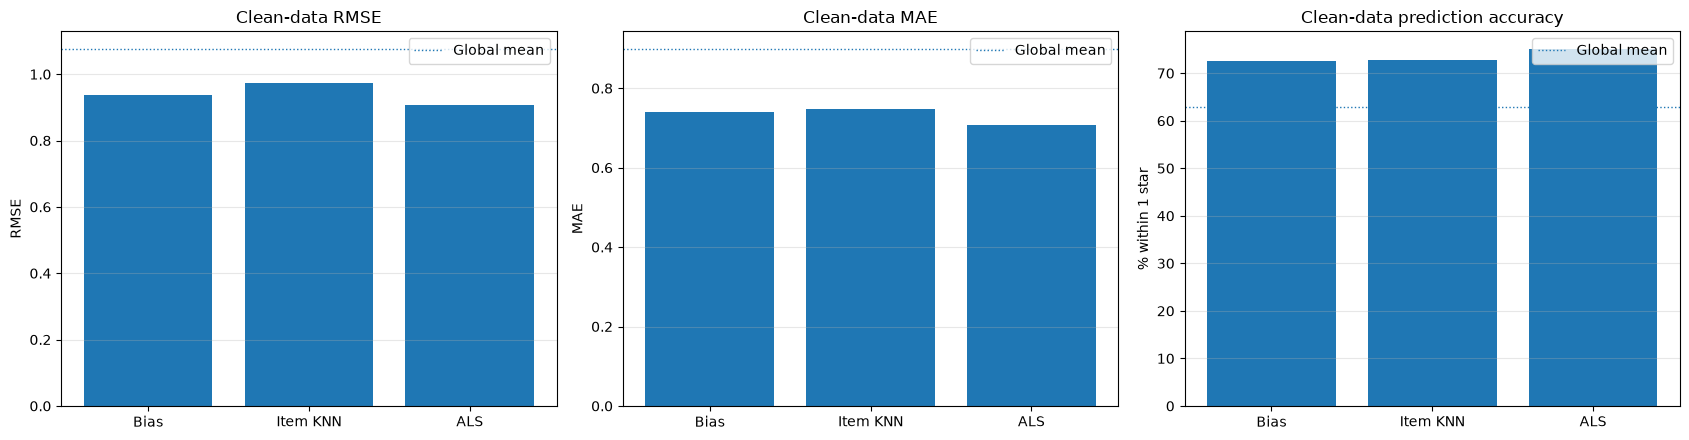

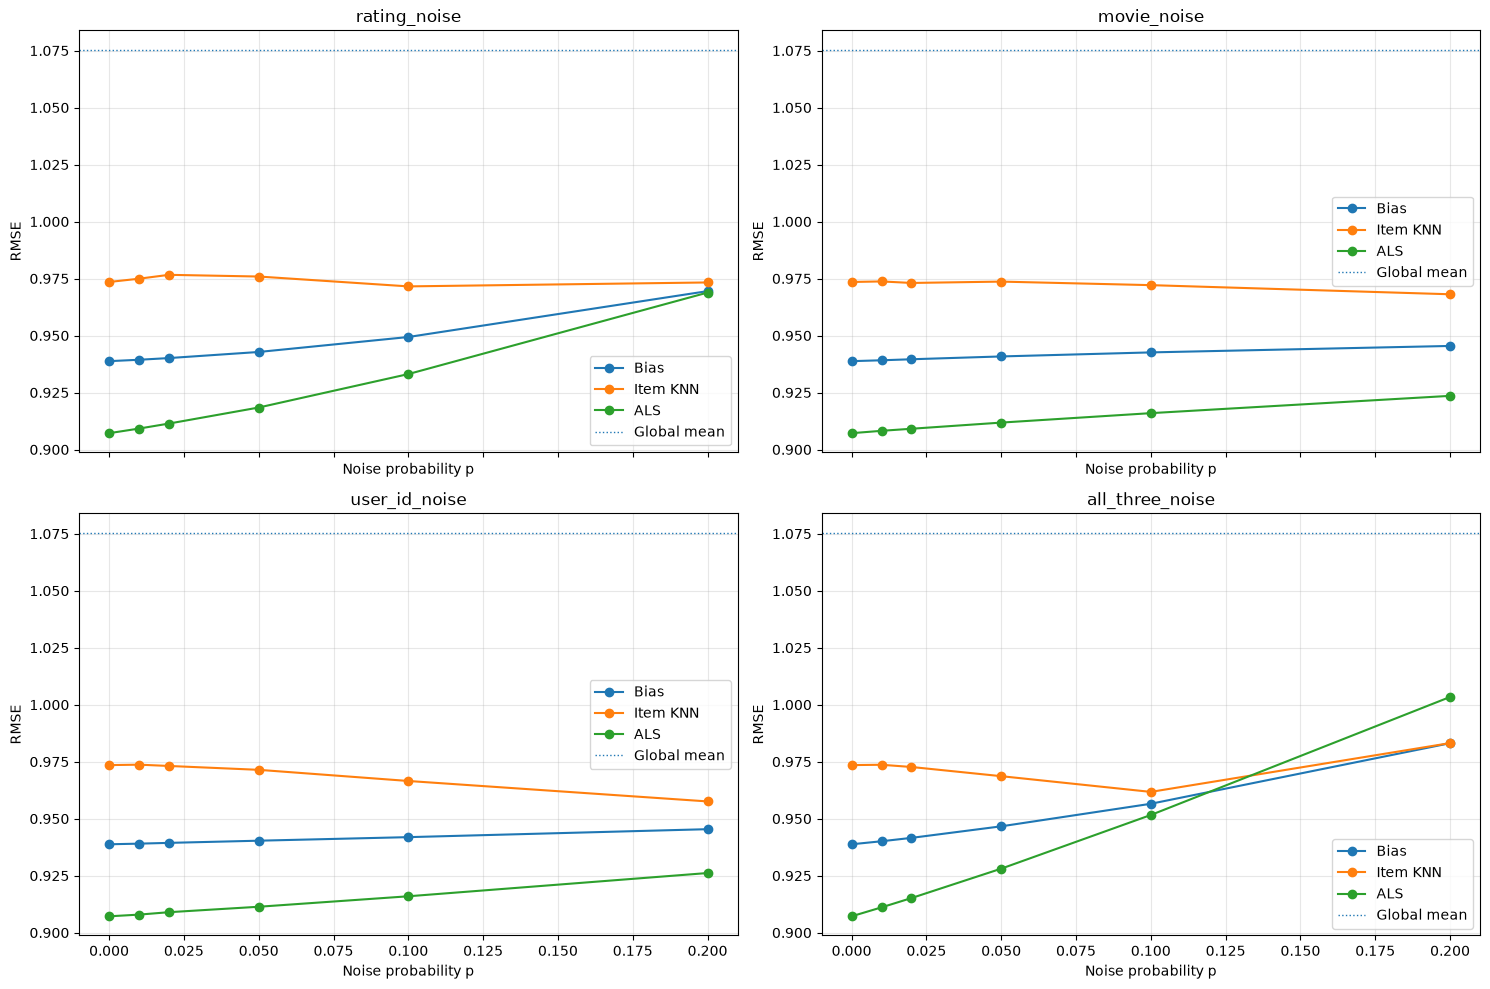

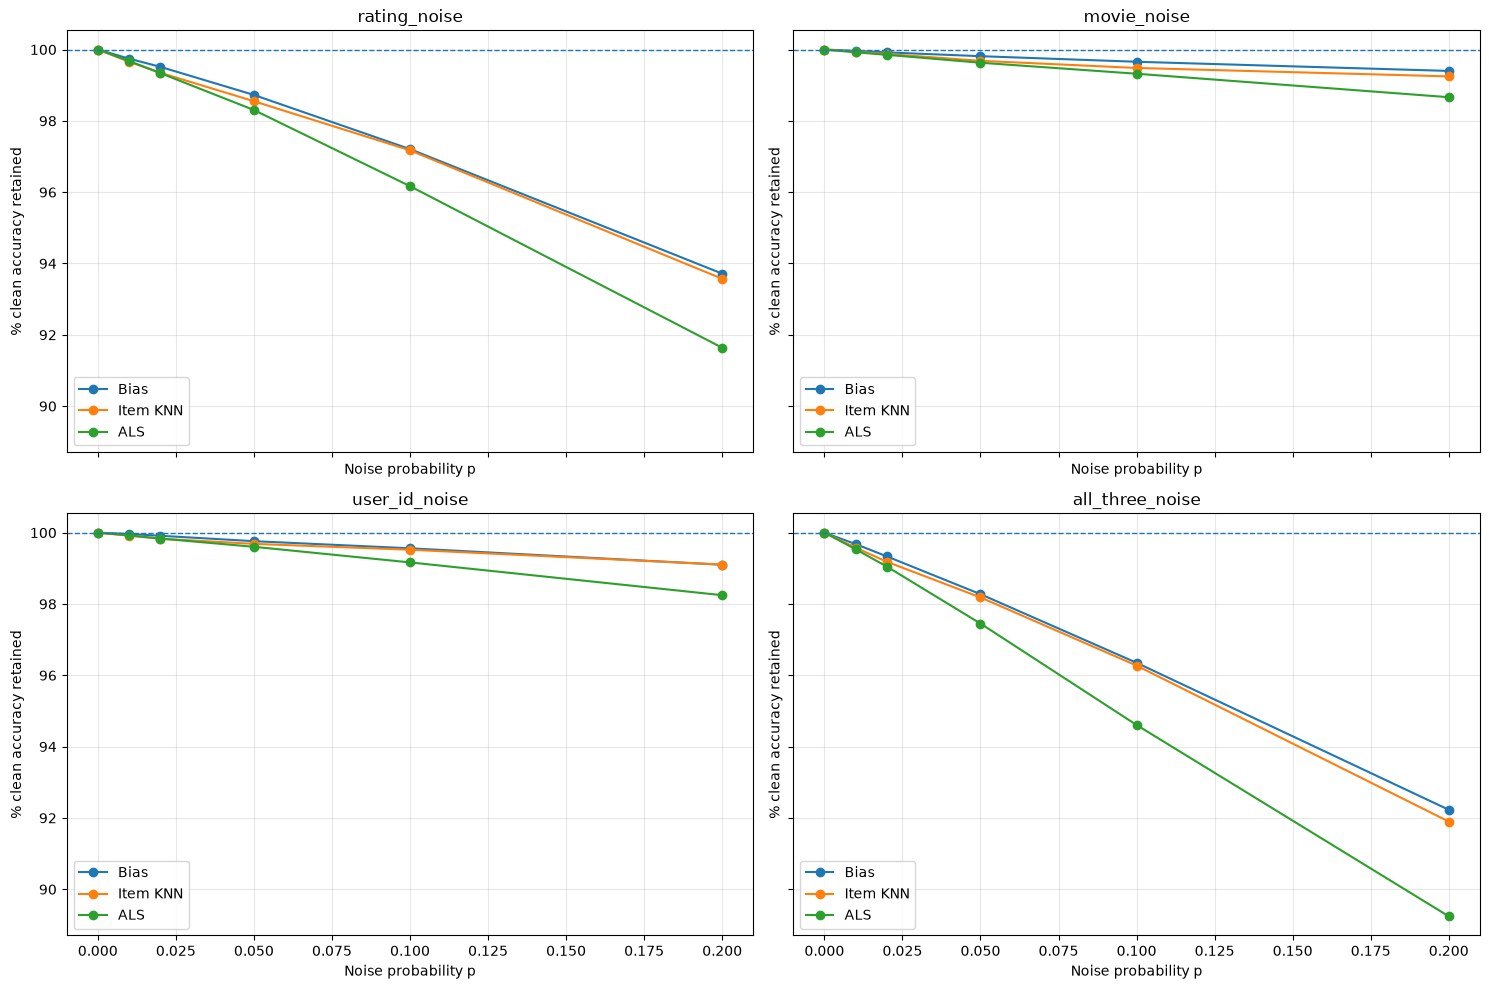

In [60]:
model_order = ["Bias", "Item KNN", "ALS"]

clean_plot = (
    clean_model_comparison
    .set_index("model")
    .loc[model_order]
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].bar(clean_plot["model"], clean_plot["rmse"])
axes[0].axhline(
    global_rmse,
    linestyle=":",
    linewidth=1,
    label="Global mean",
)
axes[0].set_ylabel("RMSE")
axes[0].set_title("Clean-data RMSE")
axes[0].legend()

axes[1].bar(clean_plot["model"], clean_plot["mae"])
axes[1].axhline(
    global_mae,
    linestyle=":",
    linewidth=1,
    label="Global mean",
)
axes[1].set_ylabel("MAE")
axes[1].set_title("Clean-data MAE")
axes[1].legend()

axes[2].bar(
    clean_plot["model"],
    clean_plot["within_1_star_pct"],
)
axes[2].axhline(
    global_within_1,
    linestyle=":",
    linewidth=1,
    label="Global mean",
)
axes[2].set_ylabel("% within 1 star")
axes[2].set_title("Clean-data prediction accuracy")
axes[2].legend()

for ax in axes:
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
)

axes = axes.ravel()

for ax, scenario in zip(axes, noise_scenarios):
    part = all_model_summary[
        all_model_summary["scenario"] == scenario
    ]

    for model_name in model_order:
        model_part = part[
            part["model"] == model_name
        ].sort_values("p")

        ax.plot(
            model_part["p"],
            model_part["rmse"],
            marker="o",
            label=model_name,
        )

    ax.axhline(
        global_rmse,
        linestyle=":",
        linewidth=1,
        label="Global mean",
    )

    ax.set_title(scenario)
    ax.set_xlabel("Noise probability p")
    ax.set_ylabel("RMSE")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for ax, scenario in zip(axes, noise_scenarios):
    part = all_model_summary[
        all_model_summary["scenario"] == scenario
    ]

    for model_name in model_order:
        model_part = part[
            part["model"] == model_name
        ].sort_values("p")

        ax.plot(
            model_part["p"],
            model_part["within_1_star_retained_pct"],
            marker="o",
            label=model_name,
        )

    ax.axhline(100, linestyle="--", linewidth=1)
    ax.set_title(scenario)
    ax.set_xlabel("Noise probability p")
    ax.set_ylabel("% clean accuracy retained")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

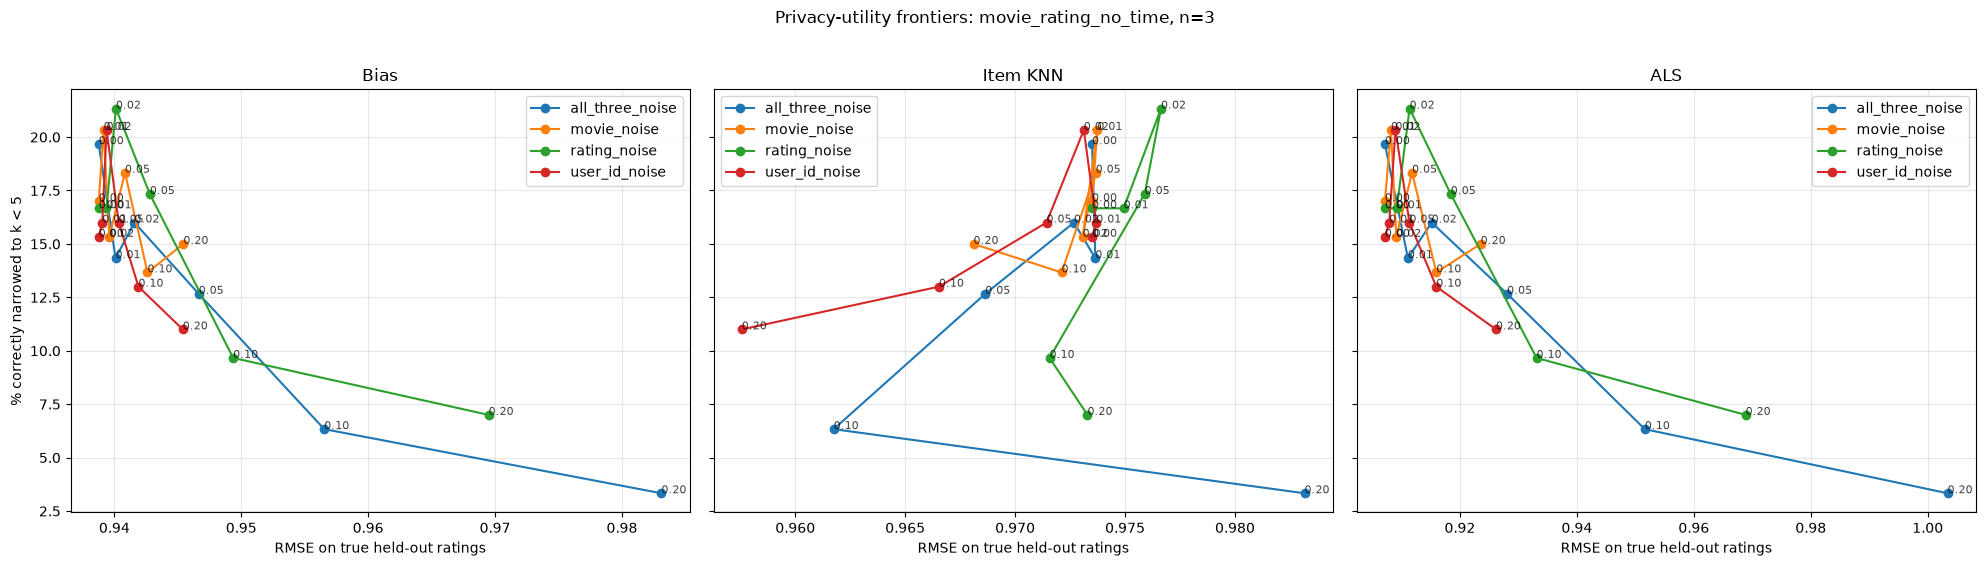

,scenario,p,model,pct_less_than_5_correct,false_positive_rate_among_less_than_5,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct
0,all_three_noise,0.00,ALS,19.666667,0.000000,0.907167,0.708069,75.054799,100.000000,100.000000
1,all_three_noise,0.00,Bias,19.666667,0.000000,0.938766,0.740148,72.464819,100.000000,100.000000
2,all_three_noise,0.00,Item KNN,19.666667,0.000000,0.973499,0.746506,72.734674,100.000000,100.000000
3,all_three_noise,0.01,ALS,14.333333,0.000000,0.911094,0.712709,74.705877,99.535111,97.666407
4,all_three_noise,0.01,Bias,14.333333,0.000000,0.940089,0.742441,72.232322,99.679158,99.032169
...,...,...,...,...,...,...,...,...,...,...
67,user_id_noise,0.10,Bias,13.000000,15.217391,0.941896,0.743728,72.146604,99.560870,97.710592
68,user_id_noise,0.10,Item KNN,13.000000,15.217391,0.966534,0.747932,72.386303,99.521038,106.829436
69,user_id_noise,0.20,ALS,11.000000,26.666667,0.926154,0.726250,73.738480,98.246189,88.718481
70,user_id_noise,0.20,Bias,11.000000,26.666667,0.945388,0.747510,71.812436,99.099724,95.156099


Saved combined_privacy_utility_all_recommenders.csv


In [61]:
PLOT_KNOWLEDGE_NAME = "movie_rating_no_time"
PLOT_N_KNOWN = 3

privacy_for_models = noise_summary[
    (noise_summary["knowledge_name"] == PLOT_KNOWLEDGE_NAME)
    & (noise_summary["n_known"] == PLOT_N_KNOWN)
].copy()

privacy_utility_all_models = privacy_for_models.merge(
    all_model_summary,
    on=["scenario", "p"],
    how="left",
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.5),
    sharey=True,
)

for ax, model_name in zip(axes, model_order):
    model_part = privacy_utility_all_models[
        privacy_utility_all_models["model"] == model_name
    ]

    for scenario, scenario_part in model_part.groupby("scenario"):
        scenario_part = scenario_part.sort_values("p")

        ax.plot(
            scenario_part["rmse"],
            scenario_part["pct_less_than_5_correct"],
            marker="o",
            label=scenario,
        )

        for _, row in scenario_part.iterrows():
            ax.annotate(
                f"{row['p']:.2f}",
                (
                    row["rmse"],
                    row["pct_less_than_5_correct"],
                ),
                fontsize=8,
                alpha=0.75,
            )

    ax.set_title(model_name)
    ax.set_xlabel("RMSE on true held-out ratings")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("% correctly narrowed to k < 5")

fig.suptitle(
    f"Privacy-utility frontiers: {PLOT_KNOWLEDGE_NAME}, n={PLOT_N_KNOWN}",
    y=1.02,
)

plt.tight_layout()
plt.show()

display(
    privacy_utility_all_models[[
        "scenario",
        "p",
        "model",
        "pct_less_than_5_correct",
        "false_positive_rate_among_less_than_5",
        "rmse",
        "mae",
        "within_1_star_pct",
        "within_1_star_retained_pct",
        "rmse_utility_retained_pct",
    ]].sort_values(["scenario", "p", "model"])
)

privacy_utility_all_models.to_csv(
    "combined_privacy_utility_all_recommenders.csv",
    index=False,
)

print("Saved combined_privacy_utility_all_recommenders.csv")